### DINOv3 ViT-S/16 (PyTorch Hub) + Segmentação

Device: cuda
Path to dataset files: /kaggle/input/lgg-mri-segmentation
/content
Checkpoint .pth em: /content/dinov3_vits16_pretrain_lvd1689m-08c60483.pth
Total de pares encontrados: 7858
#itens: train=6286 val=785 test=787
Feature map inicial: (8, 384, 14, 14) embed_dim: 384


/tmp/ipython-input-1732932823.py:366: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))
/tmp/ipython-input-1732932823.py:378: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


[01/50] train_loss=0.2455 IoU=nan Dice=0.5404 | val_loss=0.1493 IoU=nan Dice=0.5595 | 101.8s
[02/50] train_loss=0.1346 IoU=nan Dice=0.6302 | val_loss=0.1271 IoU=nan Dice=0.6192 | 101.6s
[03/50] train_loss=0.1298 IoU=nan Dice=0.6584 | val_loss=0.1328 IoU=nan Dice=0.5986 | 101.9s
[04/50] train_loss=0.1154 IoU=nan Dice=0.6821 | val_loss=0.1107 IoU=nan Dice=0.6467 | 102.1s
[05/50] train_loss=0.1132 IoU=nan Dice=0.6876 | val_loss=0.1041 IoU=nan Dice=0.6731 | 102.1s
[06/50] train_loss=0.1109 IoU=nan Dice=0.6836 | val_loss=0.1058 IoU=nan Dice=0.6758 | 102.0s
[07/50] train_loss=0.1089 IoU=nan Dice=0.7101 | val_loss=0.1002 IoU=nan Dice=0.6762 | 101.6s
[08/50] train_loss=0.1042 IoU=nan Dice=0.7048 | val_loss=0.0887 IoU=nan Dice=0.6811 | 102.5s
[09/50] train_loss=0.0998 IoU=nan Dice=0.7105 | val_loss=0.0923 IoU=nan Dice=0.6992 | 102.0s
[10/50] train_loss=0.1023 IoU=nan Dice=0.7092 | val_loss=0.0899 IoU=nan Dice=0.6858 | 101.8s
[11/50] train_loss=0.0997 IoU=nan Dice=0.7202 | val_loss=0.0919 IoU=na

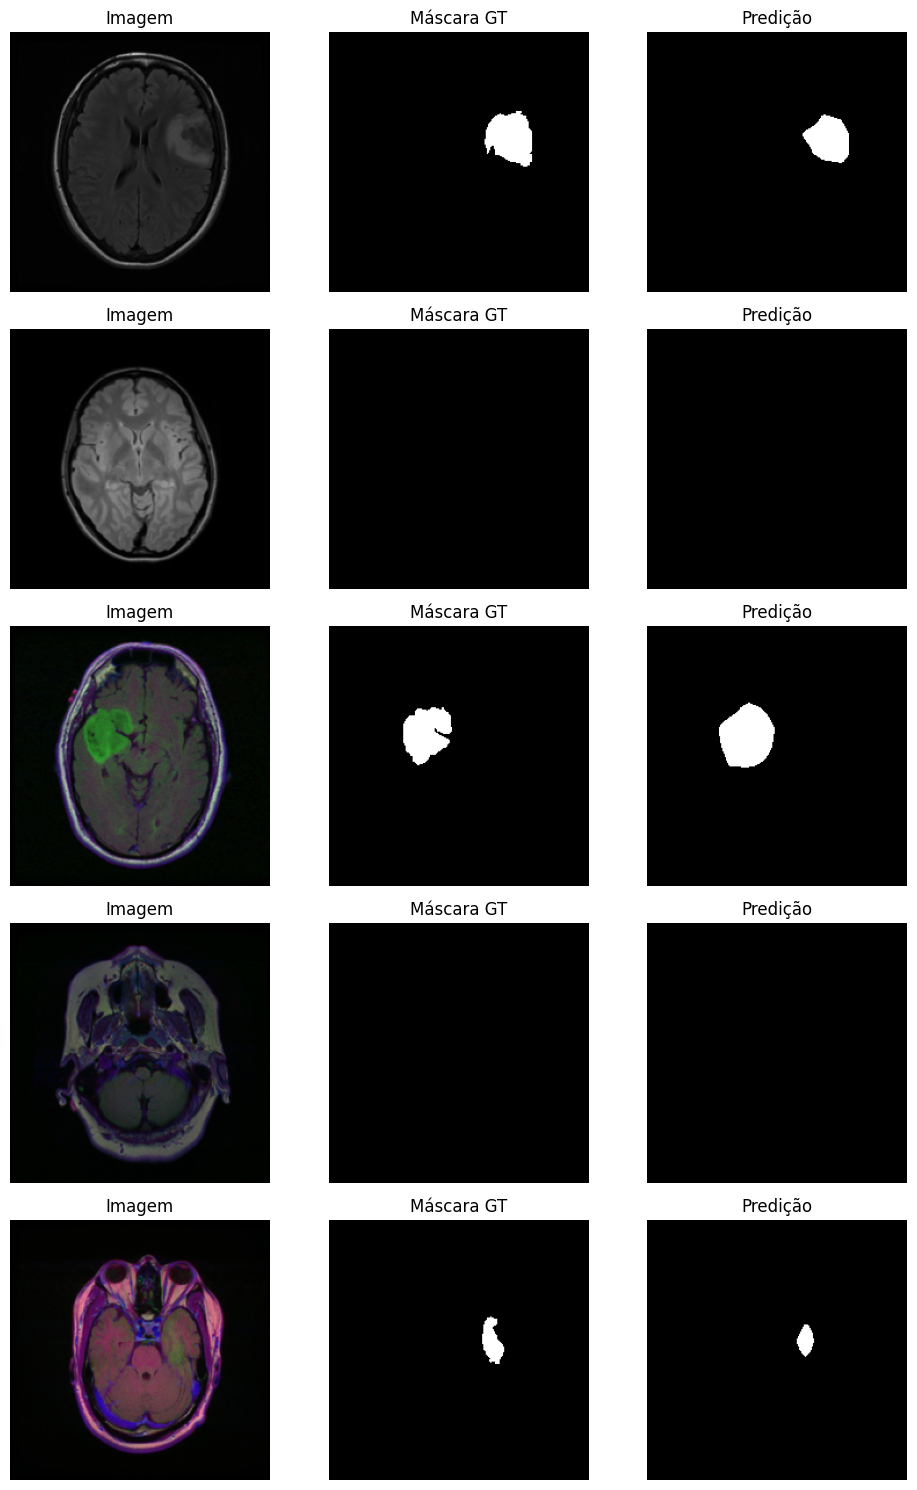

In [ ]:



!pip -q install kagglehub==0.3.4 timm==1.0.9 torchmetrics==1.4.0.post0 opencv-python==4.10.0.84


import os, sys, math, glob, random, time
from pathlib import Path
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms as T
from torchmetrics.classification import BinaryJaccardIndex, BinaryF1Score
import matplotlib.pyplot as pltc
import kagglehub


SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# Baixa o dataset do Kaggle

path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")
print("Path to dataset files:", path)
DATA_ROOT = Path(path)


# Clonar dinov3 e baixar o checkpoint .pth solicitado

%cd /content
if not Path("dinov3").exists():
    !git clone -q https://github.com/facebookresearch/dinov3.git

# o README orienta usar wget p/ baixar pesos (em vez do browser)
# e permite passar o caminho local/URL direto em torch.hub.load(weights=...).

ckpt_url = "https://dinov3.llamameta.net/dinov3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoiZWxyc2c2YzU3eGhpMXVqejV5bDdxNmhiIiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3NTgxNTE0ODJ9fX1dfQ__&Signature=ssy7icAYEwZK1hFKSy4f7yp6vnK6X3vaCeUbjebGmS4aP-R--RypCIR3uksrctJ05%7ENJYseSFOvuLTX8sYUFdF1Z7xF0BURQxBb4-kHWWidc9-gMBXHYGJwW825E4lyAE3uhzsyFHRjDOToz3WXXWXCHswfDRqhp6%7ExLPsJJUDJfDsTtENDUa23fOxFSvKZgHZPSDd%7ElIZRJHidG54i%7E9QtKceEAynca--nX2xaQqLFt1OriyZo99JuZ9JeXLEDb-ZXGJjcHRqtbJZS50gNoToj6qsxY7k72OkbvjQcnJhTWY8eF2k0NiqDBXr8B3u3HuRMgJg%7Et%7EoNpfW7qH7HxfA__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=772110548749499"
ckpt_path = "/content/dinov3_vits16_pretrain_lvd1689m-08c60483.pth"
if not Path(ckpt_path).exists():
    !wget -q --content-disposition -O "{ckpt_path}" "{ckpt_url}"
print("Checkpoint .pth em:", ckpt_path)


# Listar pares (imagem, máscara)

def find_image_mask_pairs(root: Path):
    img_exts = {".png",".jpg",".jpeg",".tif",".tiff"}
    all_imgs = [p for p in root.rglob("*") if p.suffix.lower() in img_exts and ("mask" not in p.stem.lower())]
    pairs = []
    for img in all_imgs:
        stem = img.stem
        cand = list(img.parent.glob(stem + "_mask.*"))
        if not cand:
            cand = [p for p in root.rglob(stem + "_mask.*")]
        if not cand:
            cand = list(img.parent.glob(stem.replace(" ","") + "mask.*"))
        if not cand:
            cand = [p for p in img.parent.glob("*") if ("mask" in p.stem.lower()) and p.suffix.lower() in img_exts]
        if cand:
            pairs.append((img, cand[0]))
    return pairs

pairs = find_image_mask_pairs(DATA_ROOT)
print(f"Total de pares encontrados: {len(pairs)}")
random.shuffle(pairs)


# Dataset e Transforms (torchvision puro)

IMG_SIZE = 224  # múltiplo de 16 => grid 14x14 (evita reshape 13x13)
mean = (0.485, 0.456, 0.406); std = (0.229, 0.224, 0.225)

train_tf = T.Compose([
    T.ToTensor(),
    T.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    T.ConvertImageDtype(torch.float32),
    T.Normalize(mean, std),
])
val_tf = T.Compose([
    T.ToTensor(),
    T.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    T.ConvertImageDtype(torch.float32),
    T.Normalize(mean, std),
])

def apply_simple_aug(img, mask):
    # Flip horizontal 50%
    if random.random() < 0.5:
        img  = np.ascontiguousarray(np.fliplr(img))
        mask = np.ascontiguousarray(np.fliplr(mask))
    # Jitter leve brilho/contraste na imagem
    if random.random() < 0.2:
        alpha = 1.0 + random.uniform(-0.2, 0.2)  # contraste
        beta  = random.uniform(-20, 20)          # brilho
        img = np.clip(alpha*img + beta, 0, 255).astype(np.uint8)
    return img, mask

class MRISegDataset(Dataset):
    def __init__(self, pairs, img_transform, is_train=False):
        self.pairs = pairs
        self.img_transform = img_transform
        self.is_train = is_train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, msk_path = self.pairs[idx]
        img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if img is None: raise RuntimeError(f"Falha ao ler imagem: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(msk_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            img_maybe = cv2.imread(str(msk_path), cv2.IMREAD_COLOR)
            if img_maybe is None: raise RuntimeError(f"Falha ao ler máscara: {msk_path}")
            mask = cv2.cvtColor(img_maybe, cv2.COLOR_BGR2GRAY)

        _, mask = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY)

        if self.is_train:
            img, mask = apply_simple_aug(img, mask)

        img_res  = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        mask_res = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        img_t = train_tf(img_res) if self.is_train else val_tf(img_res)
        mask_t = torch.from_numpy((mask_res > 0).astype(np.float32))[None, ...]
        return img_t, mask_t

# Split 80/10/10
n_total = len(pairs)
n_train = int(0.8 * n_total); n_val = int(0.1 * n_total); n_test = n_total - n_train - n_val
ds_train = MRISegDataset(pairs[:n_train], img_transform=train_tf, is_train=True)
ds_val   = MRISegDataset(pairs[n_train:n_train+n_val], img_transform=val_tf, is_train=False)
ds_test  = MRISegDataset(pairs[n_train+n_val:], img_transform=val_tf, is_train=False)

batch_size = 8
train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
print(f"#itens: train={len(ds_train)} val={len(ds_val)} test={len(ds_test)}")


# Carregar ViT-S/16 via PyTorch Hub (local) — extração robusta de PATCH TOKENS

REPO_DIR = "/content/dinov3"
dinov3_vits16 = torch.hub.load(
    REPO_DIR,
    'dinov3_vits16',
    source='local',
    weights=ckpt_path  # usamos exatamente o .pth que você baixou (conforme o README)
).to(device).eval()

IMG_PATCH = 16
GRID_HW = (IMG_SIZE // IMG_PATCH) * (IMG_SIZE // IMG_PATCH)

def _pick_best_tensor(candidates, img_size=IMG_SIZE, patch=IMG_PATCH):
    """Escolhe o tensor que parece ser o de patches: [B,N(+1),C] com N≈grid, ou [B,C,H',W'] com H'*W'≈grid."""
    grid = (img_size // patch) * (img_size // patch)
    # Prioridade 1: [B, N(+1), C] com N==grid ou N==grid+1
    for t in candidates:
        if not torch.is_tensor(t):
            continue
        if t.ndim == 3:
            B, N, C = t.shape
            if N in (grid, grid+1) and C >= 128:  # C >=128 para descartar tensores muito estreitos
                return t
    # Prioridade 2: [B, C, H', W'] com H'*W'==grid
    for t in candidates:
        if not torch.is_tensor(t):
            continue
        if t.ndim == 4:
            B, C, H, W = t.shape
            if H * W == grid and C >= 128:
                # convertemos depois
                return t
    # Se nada “perfeito”, devolve None
    return None

def _collect_forward_tensors(m, x):
    """Roda um forward com hooks em TODOS os submódulos e coleta saídas candidatas."""
    candidates = []
    handles = []

    def hook(_, __, out):
        # guarda tensores diretamente; se for tupla/dict, tentamos extrair tensores
        if torch.is_tensor(out):
            candidates.append(out)
        elif isinstance(out, (list, tuple)):
            candidates.extend([t for t in out if torch.is_tensor(t)])
        elif isinstance(out, dict):
            candidates.extend([v for v in out.values() if torch.is_tensor(v)])

    # registra hooks em todos os submódulos
    for sub in m.modules():
        try:
            h = sub.register_forward_hook(hook)
            handles.append(h)
        except Exception:
            pass

    with torch.inference_mode():
        _ = m(x)  # forward padrão (mesmo que devolva só [B,C], os hooks capturam intermediários)

    # limpa hooks
    for h in handles:
        try: h.remove()
        except Exception: pass

    return candidates

def extract_patch_tokens(backbone, x, img_size=IMG_SIZE, patch=IMG_PATCH):
    """Retorna feature map [B,C,H',W'] (H'=W'=IMG_SIZE/patch). Usa:
       1) get_intermediate_layers (se existir), 2) forward_features (se existir),
       3) HOOKS (varredura geral) — robusto a variações do hub."""
    grid = (img_size // patch) * (img_size // patch)

    with torch.inference_mode():
        # 1) get_intermediate_layers
        if hasattr(backbone, "get_intermediate_layers"):
            try:
                outs = backbone.get_intermediate_layers(x, n=1, return_class_token=True)
            except TypeError:
                try: outs = backbone.get_intermediate_layers(x, 1, True)
                except TypeError: outs = backbone.get_intermediate_layers(x, 1)
            if isinstance(outs, (list, tuple)):
                # pegue o primeiro tensor plausível
                z = next((t for t in outs if torch.is_tensor(t) and t.ndim in (3,4)), None)
                if z is not None:
                    if z.ndim == 4:
                        return z  # [B,C,H',W']
                    B, N, C = z.shape
                    if N == grid + 1: z = z[:, 1:, :]
                    if z.ndim == 3 and z.shape[1] == grid:
                        h = w = img_size // patch
                        return z.transpose(1, 2).reshape(B, C, h, w).contiguous()

        # 2) forward_features
        if hasattr(backbone, "forward_features"):
            feat = backbone.forward_features(x)
            # dict/tuple/tensor
            pool = []
            if torch.is_tensor(feat):
                pool = [feat]
            elif isinstance(feat, (list, tuple)):
                pool = [t for t in feat if torch.is_tensor(t)]
            elif isinstance(feat, dict):
                pool = [v for v in feat.values() if torch.is_tensor(v)]
            # tenta escolher o melhor candidato
            z = _pick_best_tensor(pool, img_size, patch)
            if z is not None:
                if z.ndim == 4:
                    return z
                B, N, C = z.shape
                if N == grid + 1: z = z[:, 1:, :]
                h = w = img_size // patch
                return z.transpose(1, 2).reshape(B, C, h, w).contiguous()

        # 3) HOOKS — varre a rede e pega o tensor correto
        cands = _collect_forward_tensors(backbone, x)
        z = _pick_best_tensor(cands, img_size, patch)
        if z is None:
            # última tentativa: se tiver só embedding [B,C], avisamos explicitamente
            only_bc = any(torch.is_tensor(t) and t.ndim == 2 for t in cands)
            if only_bc:
                raise RuntimeError("O hub devolveu apenas embeddings globais [B,C] e nenhum tensor [B,N,C] ou [B,C,H',W'] durante o forward. "
                                   "Ative camadas intermediárias ou use uma função de features (get_intermediate_layers/forward_features).")
            raise RuntimeError("Não foi possível localizar tokens de patch nem feature map nos intermediários do backbone.")

        # normaliza z para [B,C,H',W']
        if z.ndim == 4:
            return z
        B, N, C = z.shape
        if N == grid + 1: z = z[:, 1:, :]
        h = w = img_size // patch
        return z.transpose(1, 2).reshape(B, C, h, w).contiguous()

# Wrapper para usar no modelo
class DinoV3FeatureExtractor(nn.Module):
    def __init__(self, backbone, img_size=IMG_SIZE, patch=IMG_PATCH):
        super().__init__()
        self.backbone = backbone
        self.img_size = img_size
        self.patch = patch
    def forward(self, x):
        return extract_patch_tokens(self.backbone, x, self.img_size, self.patch)

# Descobrir embed_dim de forma automática
with torch.no_grad():
    xb, yb = next(iter(train_loader))
    xb = xb.to(device)
    fmap = extract_patch_tokens(dinov3_vits16, xb, img_size=IMG_SIZE, patch=IMG_PATCH)  # [B,C,14,14] para 224
embed_dim = fmap.shape[1]
print("Feature map inicial:", tuple(fmap.shape), "embed_dim:", embed_dim)

feat_extractor = DinoV3FeatureExtractor(dinov3_vits16, img_size=IMG_SIZE, patch=IMG_PATCH).to(device)




# Decoder leve de segmentação

patch_size = 16  # ViT-S/16
class SimpleDecoder(nn.Module):
    def __init__(self, in_ch, out_ch=1, up_factor=patch_size):
        super().__init__()
        self.up1 = nn.Sequential(
            nn.Conv2d(in_ch, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        self.up = nn.Upsample(scale_factor=up_factor, mode='bilinear', align_corners=False)
        self.head = nn.Sequential(
            nn.Conv2d(256, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, out_ch, 1)
        )
    def forward(self, f):
        x = self.up1(f)
        x = self.up(x)
        x = self.head(x)
        return x

class SegModel(nn.Module):
    def __init__(self, feat_extractor, in_ch):
        super().__init__()
        self.backbone = feat_extractor
        self.decoder = SimpleDecoder(in_ch, out_ch=1, up_factor=patch_size)
    def forward(self, x):
        with torch.no_grad():
            f = self.backbone(x)      # [B,C,14,14]
        logits = self.decoder(f)       # [B,1,224,224]
        return logits

model = SegModel(feat_extractor, in_ch=embed_dim).to(device)


# Perdas, otimizador e métricas

def dice_loss(pred, target, eps=1e-6):
    num = 2 * (pred * target).sum(dim=(2,3)) + eps
    den = (pred + target).sum(dim=(2,3)) + eps
    return 1 - (num / den).mean()

bce = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.decoder.parameters(), lr=1e-3, weight_decay=1e-4)
metric_iou = BinaryJaccardIndex().to(device)
metric_f1  = BinaryF1Score().to(device)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))


# Loop de treino/val

def run_epoch(loader, model, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    running_loss = running_iou = running_dice = 0.0
    n_batches = 0
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            logits = model(xb)
            prob = torch.sigmoid(logits)
            loss = 0.5*bce(logits, yb) + 0.5*dice_loss(prob, yb)
        if is_train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        pred_bin = (prob > 0.5).to(torch.int)
        targ_bin = (yb > 0.5).to(torch.int)
        iou = metric_iou(pred_bin, targ_bin).item()
        f1  = metric_f1(pred_bin, targ_bin).item()
        running_loss += loss.item(); running_iou += iou; running_dice += f1; n_batches += 1
    return running_loss/n_batches, running_iou/n_batches, running_dice/n_batches

EPOCHS = 50
best_val = 0.0
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_iou, tr_dice = run_epoch(train_loader, model, optimizer)
    with torch.no_grad():
        va_loss, va_iou, va_dice = run_epoch(val_loader, model, optimizer=None)
    print(f"[{epoch:02d}/{EPOCHS}] "
          f"train_loss={tr_loss:.4f} IoU={tr_iou:.4f} Dice={tr_dice:.4f} | "
          f"val_loss={va_loss:.4f} IoU={va_iou:.4f} Dice={va_dice:.4f} | {time.time()-t0:.1f}s")
    if va_dice > best_val:
        best_val = va_dice
        torch.save(model.state_dict(), "/content/dinov3_vits16_lgg_seg_best.pt")

print("Treino finalizado. Melhor Dice (val):", best_val)


# Avaliação no teste + Visualização

with torch.no_grad():
    te_loss, te_iou, te_dice = run_epoch(test_loader, model, optimizer=None)
print(f"[TEST] loss={te_loss:.4f} IoU={te_iou:.4f} Dice={te_dice:.4f}")

def show_examples(loader, model, k=5):
    model.eval()
    xb_all, yb_all = next(iter(loader))
    xb_all, yb_all = xb_all.to(device), yb_all.to(device)
    with torch.no_grad():
        logits = model(xb_all)
        prob = torch.sigmoid(logits)
        pred = (prob > 0.5).float()
    # desnormaliza p/ visualização
    std = np.array((0.229, 0.224, 0.225)); mean = np.array((0.485, 0.456, 0.406))
    xb_all = xb_all.cpu().numpy().transpose(0,2,3,1)
    xb_vis = xb_all * std[None,None,None,:] + mean[None,None,None,:]
    xb_vis = np.clip(xb_vis, 0.0, 1.0)
    rows = min(k, xb_vis.shape[0])
    plt.figure(figsize=(10, 3*rows))
    for i in range(rows):
        plt.subplot(rows,3,3*i+1); plt.imshow(xb_vis[i]); plt.axis('off'); plt.title("Imagem")
        plt.subplot(rows,3,3*i+2); plt.imshow(yb_all[i,0].cpu(), cmap='gray'); plt.axis('off'); plt.title("Máscara GT")
        plt.subplot(rows,3,3*i+3); plt.imshow(pred[i,0].cpu(), cmap='gray'); plt.axis('off'); plt.title("Predição")
    plt.tight_layout(); plt.show()

show_examples(test_loader, model, k=5)


## DINOv3 ViT-S/16 (PyTorch Hub) + Segmentação

Device: cuda
Path to dataset files: /kaggle/input/lgg-mri-segmentation
/content
Checkpoint .pth em: /content/dinov3_vits16_pretrain_lvd1689m-08c60483.pth
Total de pares encontrados: 7858
#itens: train=6286 val=785 test=787
Feature map inicial: (4, 384, 28, 28) embed_dim: 384
[01/50] train_loss=0.4224 IoU=0.3100 Dice=0.4753 | val_loss=0.4114 IoU=0.3812 Dice=0.5269 | 116.6s
[02/50] train_loss=0.3864 IoU=0.3983 Dice=0.5849 | val_loss=0.3945 IoU=0.3793 Dice=0.5649 | 91.2s
[03/50] train_loss=0.3802 IoU=0.4178 Dice=0.6078 | val_loss=0.3894 IoU=0.4480 Dice=0.6019 | 91.9s
[04/50] train_loss=0.3770 IoU=0.4358 Dice=0.6228 | val_loss=0.3895 IoU=0.4574 Dice=0.5989 | 91.9s
[05/50] train_loss=0.3744 IoU=0.4479 Dice=0.6311 | val_loss=0.3920 IoU=0.4642 Dice=0.5973 | 91.8s
[06/50] train_loss=0.3719 IoU=0.4606 Dice=0.6439 | val_loss=0.3909 IoU=0.3360 Dice=0.5560 | 92.1s
[07/50] train_loss=0.3698 IoU=0.4637 Dice=0.6426 | val_loss=0.3868 IoU=0.4875 Dice=0.6077 | 92.1s
[08/50] train_loss=0.3680 IoU=0.4900 

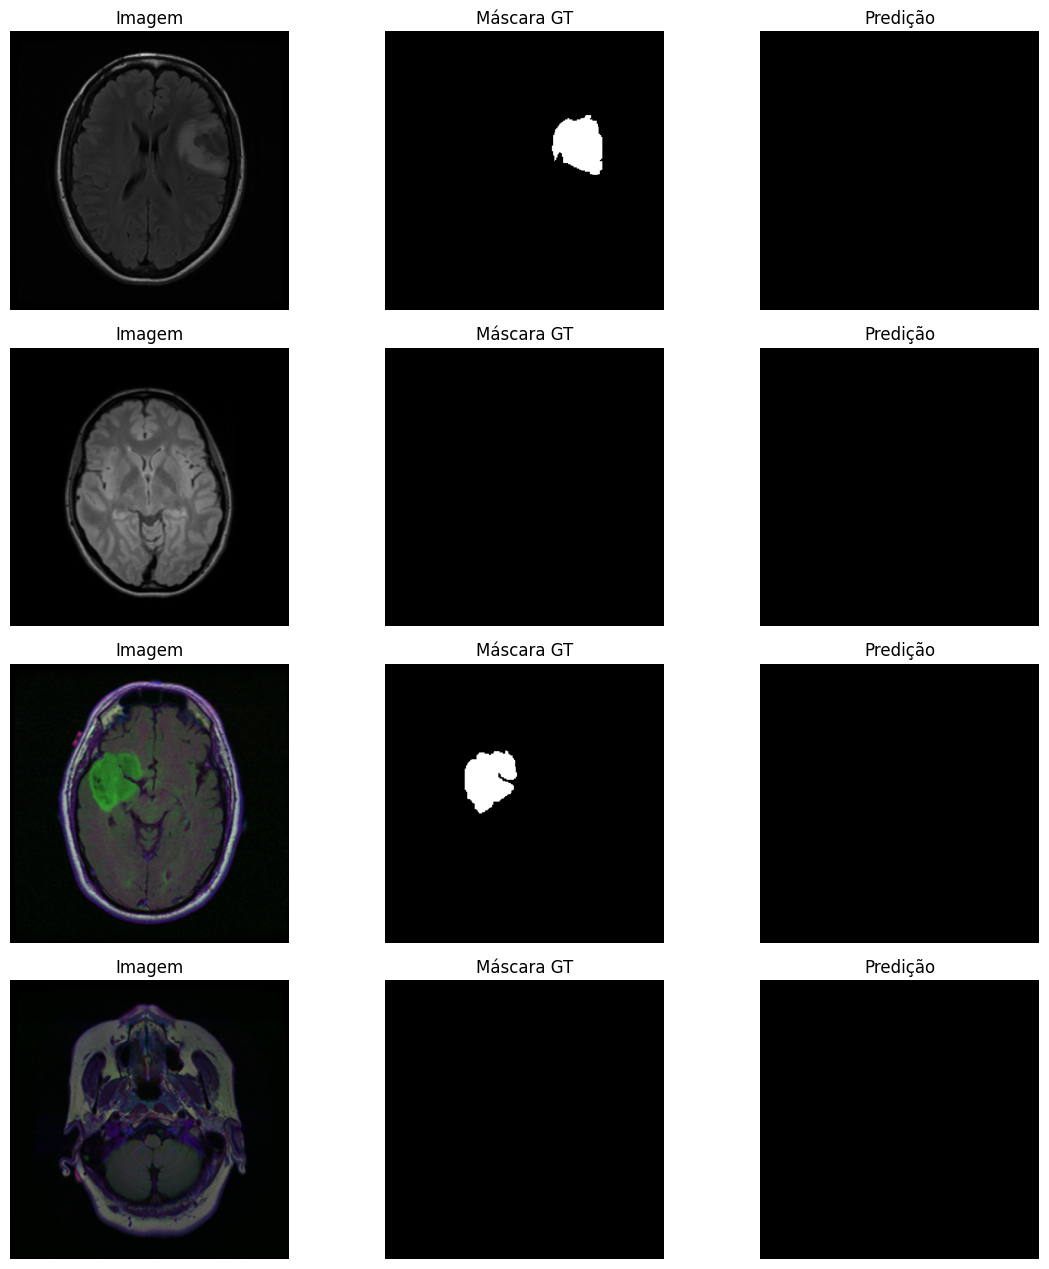

In [ ]:

!pip -q install kagglehub==0.3.4 timm==1.0.9 torchmetrics==1.4.0.post0 opencv-python==4.10.0.84

import os, sys, math, glob, random, time
from pathlib import Path
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms as T
from torchmetrics.classification import BinaryF1Score
import matplotlib.pyplot as plt
import kagglehub


SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# Baixa o dataset do Kaggle

path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")
print("Path to dataset files:", path)
DATA_ROOT = Path(path)


# Clonar dinov3 e baixar o checkpoint .pth solicitado

%cd /content
if not Path("dinov3").exists():
    !git clone -q https://github.com/facebookresearch/dinov3.git

ckpt_url = "https://dinov3.llamameta.net/dinov3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoiZWxyc2c2YzU3eGhpMXVqejV5bDdxNmhiIiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3NTgxNTE0ODJ9fX1dfQ__&Signature=ssy7icAYEwZK1hFKSy4f7yp6vnK6X3vaCeUbjebGmS4aP-R--RypCIR3uksrctJ05%7ENJYseSFOvuLTX8sYUFdF1Z7xF0BURQxBb4-kHWWidc9-gMBXHYGJwW825E4lyAE3uhzsyFHRjDOToz3WXXWXCHswfDRqhp6%7ExLPsJJUDJfDsTtENDUa23fOxFSvKZgHZPSDd%7ElIZRJHidG54i%7E9QtKceEAynca--nX2xaQqLFt1OriyZo99JuZ9JeXLEDb-ZXGJjcHRqtbJZS50gNoToj6qsxY7k72OkbvjQcnJhTWY8eF2k0NiqDBXr8B3u3HuRMgJg%7Et%7EoNpfW7qH7HxfA__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=772110548749499"
ckpt_path = "/content/dinov3_vits16_pretrain_lvd1689m-08c60483.pth"
if not Path(ckpt_path).exists():
    !wget -q --content-disposition -O "{ckpt_path}" "{ckpt_url}"
print("Checkpoint .pth em:", ckpt_path)


# Listar pares (imagem, máscara)

def find_image_mask_pairs(root: Path):
    img_exts = {".png",".jpg",".jpeg",".tif",".tiff"}
    all_imgs = [p for p in root.rglob("*") if p.suffix.lower() in img_exts and ("mask" not in p.stem.lower())]
    pairs = []
    for img in all_imgs:
        stem = img.stem
        cand = list(img.parent.glob(stem + "_mask.*"))
        if not cand:
            cand = [p for p in root.rglob(stem + "_mask.*")]
        if not cand:
            cand = list(img.parent.glob(stem.replace(" ","") + "mask.*"))
        if not cand:
            cand = [p for p in img.parent.glob("*") if ("mask" in p.stem.lower()) and p.suffix.lower() in img_exts]
        if cand:
            pairs.append((img, cand[0]))
    return pairs

pairs = find_image_mask_pairs(DATA_ROOT)
print(f"Total de pares encontrados: {len(pairs)}")
random.shuffle(pairs)



IMG_SIZE = 448  # -> grid 28x28 para ViT-S/16
mean = (0.485, 0.456, 0.406); std = (0.229, 0.224, 0.225)

train_tf = T.Compose([
    T.ToTensor(),
    T.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    T.ConvertImageDtype(torch.float32),
    T.Normalize(mean, std),
])
val_tf = T.Compose([
    T.ToTensor(),
    T.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    T.ConvertImageDtype(torch.float32),
    T.Normalize(mean, std),
])

def apply_simple_aug(img, mask):
    if random.random() < 0.5:
        img  = np.ascontiguousarray(np.fliplr(img))
        mask = np.ascontiguousarray(np.fliplr(mask))
    if random.random() < 0.2:
        alpha = 1.0 + random.uniform(-0.2, 0.2)
        beta  = random.uniform(-20, 20)
        img = np.clip(alpha*img + beta, 0, 255).astype(np.uint8)
    return img, mask

class MRISegDataset(Dataset):
    def __init__(self, pairs, img_transform, is_train=False):
        self.pairs = pairs
        self.img_transform = img_transform
        self.is_train = is_train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, msk_path = self.pairs[idx]
        img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if img is None: raise RuntimeError(f"Falha ao ler imagem: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(msk_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            img_maybe = cv2.imread(str(msk_path), cv2.IMREAD_COLOR)
            if img_maybe is None: raise RuntimeError(f"Falha ao ler máscara: {msk_path}")
            mask = cv2.cvtColor(img_maybe, cv2.COLOR_BGR2GRAY)

        _, mask = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY)

        if self.is_train:
            img, mask = apply_simple_aug(img, mask)

        img_res  = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        mask_res = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        img_t = train_tf(img_res) if self.is_train else val_tf(img_res)
        mask_t = torch.from_numpy((mask_res > 0).astype(np.float32))[None, ...]
        return img_t, mask_t

# Split 80/10/10
n_total = len(pairs)
n_train = int(0.8 * n_total); n_val = int(0.1 * n_total); n_test = n_total - n_train - n_val
ds_train = MRISegDataset(pairs[:n_train], img_transform=train_tf, is_train=True)
ds_val   = MRISegDataset(pairs[n_train:n_train+n_val], img_transform=val_tf, is_train=False)
ds_test  = MRISegDataset(pairs[n_train+n_val:], img_transform=val_tf, is_train=False)

# Batch menor por conta do 448x448
batch_size = 4
train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"#itens: train={len(ds_train)} val={len(ds_val)} test={len(ds_test)}")


# Carregar ViT-S/16 via PyTorch Hub (local) — extração robusta de PATCH TOKENS

REPO_DIR = "/content/dinov3"
dinov3_vits16 = torch.hub.load(
    REPO_DIR,
    'dinov3_vits16',
    source='local',
    weights=ckpt_path
).to(device).eval()

IMG_PATCH = 16  # ViT-S/16
GRID_HW = (IMG_SIZE // IMG_PATCH) * (IMG_SIZE // IMG_PATCH)  # 28*28

def _pick_best_tensor(candidates, img_size=IMG_SIZE, patch=IMG_PATCH):
    grid = (img_size // patch) * (img_size // patch)
    for t in candidates:
        if not torch.is_tensor(t):
            continue
        if t.ndim == 3:
            B, N, C = t.shape
            if N in (grid, grid+1) and C >= 128:
                return t
    for t in candidates:
        if not torch.is_tensor(t):
            continue
        if t.ndim == 4:
            B, C, H, W = t.shape
            if H * W == grid and C >= 128:
                return t
    return None

def _collect_forward_tensors(m, x):
    candidates, handles = [], []
    def hook(_, __, out):
        if torch.is_tensor(out):
            candidates.append(out)
        elif isinstance(out, (list, tuple)):
            candidates.extend([t for t in out if torch.is_tensor(t)])
        elif isinstance(out, dict):
            candidates.extend([v for v in out.values() if torch.is_tensor(v)])
    for sub in m.modules():
        try:
            h = sub.register_forward_hook(hook)
            handles.append(h)
        except Exception:
            pass
    with torch.inference_mode():
        _ = m(x)
    for h in handles:
        try: h.remove()
        except Exception: pass
    return candidates

def extract_patch_tokens(backbone, x, img_size=IMG_SIZE, patch=IMG_PATCH):
    grid = (img_size // patch) * (img_size // patch)
    with torch.inference_mode():
        if hasattr(backbone, "get_intermediate_layers"):
            try:
                outs = backbone.get_intermediate_layers(x, n=1, return_class_token=True)
            except TypeError:
                try: outs = backbone.get_intermediate_layers(x, 1, True)
                except TypeError: outs = backbone.get_intermediate_layers(x, 1)
            if isinstance(outs, (list, tuple)):
                z = next((t for t in outs if torch.is_tensor(t) and t.ndim in (3,4)), None)
                if z is not None:
                    if z.ndim == 4: return z
                    B, N, C = z.shape
                    if N == grid + 1: z = z[:, 1:, :]
                    if z.ndim == 3 and z.shape[1] == grid:
                        h = w = img_size // patch
                        return z.transpose(1, 2).reshape(B, C, h, w).contiguous()
        if hasattr(backbone, "forward_features"):
            feat = backbone.forward_features(x)
            pool = []
            if torch.is_tensor(feat): pool = [feat]
            elif isinstance(feat, (list, tuple)): pool = [t for t in feat if torch.is_tensor(t)]
            elif isinstance(feat, dict): pool = [v for v in feat.values() if torch.is_tensor(v)]
            z = _pick_best_tensor(pool, img_size, patch)
            if z is not None:
                if z.ndim == 4: return z
                B, N, C = z.shape
                if N == grid + 1: z = z[:, 1:, :]
                h = w = img_size // patch
                return z.transpose(1, 2).reshape(B, C, h, w).contiguous()
        cands = _collect_forward_tensors(backbone, x)
        z = _pick_best_tensor(cands, img_size, patch)
        if z is None:
            only_bc = any(torch.is_tensor(t) and t.ndim == 2 for t in cands)
            if only_bc:
                raise RuntimeError("Hub retornou apenas embeddings [B,C]; não encontrei tokens/feature map.")
            raise RuntimeError("Não localizei tokens de patch nem feature map nos intermediários.")
        if z.ndim == 4: return z
        B, N, C = z.shape
        if N == grid + 1: z = z[:, 1:, :]
        h = w = img_size // patch
        return z.transpose(1, 2).reshape(B, C, h, w).contiguous()

class DinoV3FeatureExtractor(nn.Module):
    def __init__(self, backbone, img_size=IMG_SIZE, patch=IMG_PATCH):
        super().__init__()
        self.backbone = backbone
        self.img_size = img_size
        self.patch = patch
    def forward(self, x):
        return extract_patch_tokens(self.backbone, x, self.img_size, self.patch)

with torch.no_grad():
    xb, yb = next(iter(train_loader))
    xb = xb.to(device)
    fmap = extract_patch_tokens(dinov3_vits16, xb, img_size=IMG_SIZE, patch=IMG_PATCH)  # [B,C,28,28]
embed_dim = fmap.shape[1]
print("Feature map inicial:", tuple(fmap.shape), "embed_dim:", embed_dim)

feat_extractor = DinoV3FeatureExtractor(dinov3_vits16, img_size=IMG_SIZE, patch=IMG_PATCH).to(device)


# Decoder estilo U-Net (multi-estágio, sem skips do encoder)
# 28x28 -> 56 -> 112 -> 224 -> 448

def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )

class UNetLikeDecoder(nn.Module):
    def __init__(self, in_ch, out_ch=1):
        super().__init__()
        self.stage1 = conv_block(in_ch, 256)   # 28x28
        self.up1    = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # 56x56

        self.stage2 = conv_block(256, 128)     # 56x56
        self.up2    = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # 112x112

        self.stage3 = conv_block(128, 64)      # 112x112
        self.up3    = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # 224x224

        self.stage4 = conv_block(64, 32)       # 224x224
        self.up4    = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # 448x448

        self.stage5 = nn.Sequential(           # 448x448
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, out_ch, 1)
        )

    def forward(self, f):
        x = self.stage1(f)
        x = self.up1(x)
        x = self.stage2(x)
        x = self.up2(x)
        x = self.stage3(x)
        x = self.up3(x)
        x = self.stage4(x)
        x = self.up4(x)
        x = self.stage5(x)
        return x

class SegModel(nn.Module):
    def __init__(self, feat_extractor, in_ch):
        super().__init__()
        self.backbone = feat_extractor
        self.decoder  = UNetLikeDecoder(in_ch, out_ch=1)
    def forward(self, x):
        with torch.no_grad():
            f = self.backbone(x)           # [B,C,28,28]
        logits = self.decoder(f)            # [B,1,448,448]
        return logits

model = SegModel(feat_extractor, in_ch=embed_dim).to(device)


# Perdas, otimizador e métricas

def dice_loss(pred, target, eps=1e-6):
    num = 2 * (pred * target).sum(dim=(2,3)) + eps
    den = (pred + target).sum(dim=(2,3)) + eps
    return 1 - (num / den).mean()

def batch_iou(pred_bin, targ_bin, eps=1e-6):
    # pred_bin, targ_bin: [B,1,H,W] int/bool
    B = pred_bin.shape[0]
    ious = []
    for b in range(B):
        p = pred_bin[b,0]; t = targ_bin[b,0]
        inter = (p & t).sum().float()
        union = (p | t).sum().float()
        if union < 1:   # ambos vazios -> ignora (não contribui)
            continue
        ious.append((inter + eps) / (union + eps))
    if len(ious) == 0:
        return torch.tensor(0.0, device=pred_bin.device)
    return torch.stack(ious).mean()

bce = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.decoder.parameters(), lr=1e-3, weight_decay=1e-4)
metric_f1  = BinaryF1Score().to(device)

# AMP recomendada nova API
scaler = torch.amp.GradScaler('cuda' if device.type=='cuda' else 'cpu')


# Loop de treino/val

def run_epoch(loader, model, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    running_loss = running_iou = running_dice = 0.0
    n_batches = 0

    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        with torch.amp.autocast(device_type='cuda' if device.type=='cuda' else 'cpu'):
            logits = model(xb)
            prob = torch.sigmoid(logits)
            loss = 0.5*bce(logits, yb) + 0.5*dice_loss(prob, yb)

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        pred_bin = (prob > 0.5).to(torch.bool)
        targ_bin = (yb  > 0.5).to(torch.bool)
        iou  = batch_iou(pred_bin, targ_bin).item()
        dice = metric_f1(pred_bin.to(torch.int), targ_bin.to(torch.int)).item()

        running_loss += loss.item(); running_iou += iou; running_dice += dice; n_batches += 1

    return running_loss/n_batches, running_iou/n_batches, running_dice/n_batches

EPOCHS = 50
best_val = 0.0
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_iou, tr_dice = run_epoch(train_loader, model, optimizer)
    with torch.no_grad():
        va_loss, va_iou, va_dice = run_epoch(val_loader, model, optimizer=None)
    print(f"[{epoch:02d}/{EPOCHS}] "
          f"train_loss={tr_loss:.4f} IoU={tr_iou:.4f} Dice={tr_dice:.4f} | "
          f"val_loss={va_loss:.4f} IoU={va_iou:.4f} Dice={va_dice:.4f} | {time.time()-t0:.1f}s")
    if va_dice > best_val:
        best_val = va_dice
        torch.save(model.state_dict(), "/content/dinov3_vits16_lgg_seg_best_448_unet.pt")

print("Treino finalizado. Melhor Dice (val):", best_val)


# Avaliação no teste + Visualização

with torch.no_grad():
    te_loss, te_iou, te_dice = run_epoch(test_loader, model, optimizer=None)
print(f"[TEST] loss={te_loss:.4f} IoU={te_iou:.4f} Dice={te_dice:.4f}")

def show_examples(loader, model, k=5):
    model.eval()
    xb_all, yb_all = next(iter(loader))
    xb_all, yb_all = xb_all.to(device), yb_all.to(device)
    with torch.no_grad():
        logits = model(xb_all)
        prob = torch.sigmoid(logits)
        pred = (prob > 0.5).float()
    std = np.array((0.229, 0.224, 0.225)); mean = np.array((0.485, 0.456, 0.406))
    xb_all = xb_all.cpu().numpy().transpose(0,2,3,1)
    xb_vis = xb_all * std[None,None,None,:] + mean[None,None,None,:]
    xb_vis = np.clip(xb_vis, 0.0, 1.0)
    rows = min(k, xb_vis.shape[0])
    plt.figure(figsize=(12, 3.2*rows))
    for i in range(rows):
        plt.subplot(rows,3,3*i+1); plt.imshow(xb_vis[i]); plt.axis('off'); plt.title("Imagem")
        plt.subplot(rows,3,3*i+2); plt.imshow(yb_all[i,0].cpu(), cmap='gray'); plt.axis('off'); plt.title("Máscara GT")
        plt.subplot(rows,3,3*i+3); plt.imshow(pred[i,0].cpu(), cmap='gray'); plt.axis('off'); plt.title("Predição")
    plt.tight_layout(); plt.show()

show_examples(test_loader, model, k=5)


## DINOv3 ViT-S/16 (PyTorch Hub) + DETECÇÂO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 38.8 MB/s eta 0:00:00
Device: cuda
Path to dataset files: /kaggle/input/lgg-mri-segmentation
/content
Checkpoint .pth em: /content/dinov3_vits16_pretrain_lvd1689m-08c60483.pth
Total de pares encontrados: 7858
#itens: train=6286 val=785 test=787
Downloading: "file:///content/dinov3_vits16_pretrain_lvd1689m-08c60483.pth" to /root/.cache/torch/hub/checkpoints/dinov3_vits16_pretrain_lvd1689m-08c60483.pth


100%|██████████| 82.5M/82.5M [00:00<00:00, 1.37GB/s]


Feature map inicial: (8, 384, 14, 14) embed_dim: 384


/tmp/ipython-input-3228164435.py:347: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))
/tmp/ipython-input-3228164435.py:387: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


[01/50] train_loss=27.3576 Precision=0.0686 Recall=0.0583 | val_loss=22.8640 Precision=0.0589 Recall=0.0340 | 61.7s
[02/50] train_loss=22.9909 Precision=0.1171 Recall=0.1008 | val_loss=23.1686 Precision=0.1742 Recall=0.1339 | 37.5s
[03/50] train_loss=21.4660 Precision=0.1691 Recall=0.1443 | val_loss=20.5369 Precision=0.0778 Recall=0.0719 | 37.0s
[04/50] train_loss=20.5162 Precision=0.1827 Recall=0.1536 | val_loss=18.8113 Precision=0.2017 Recall=0.2096 | 36.5s
[05/50] train_loss=19.0480 Precision=0.1871 Recall=0.1771 | val_loss=18.6461 Precision=0.1533 Recall=0.1034 | 36.6s
[06/50] train_loss=18.2534 Precision=0.2088 Recall=0.1944 | val_loss=18.3302 Precision=0.1454 Recall=0.1052 | 36.6s
[07/50] train_loss=17.6817 Precision=0.2131 Recall=0.1909 | val_loss=17.7259 Precision=0.1964 Recall=0.2810 | 37.0s
[08/50] train_loss=17.1863 Precision=0.2310 Recall=0.2158 | val_loss=16.9968 Precision=0.1305 Recall=0.1039 | 37.0s
[09/50] train_loss=16.4793 Precision=0.2293 Recall=0.2184 | val_loss=16.

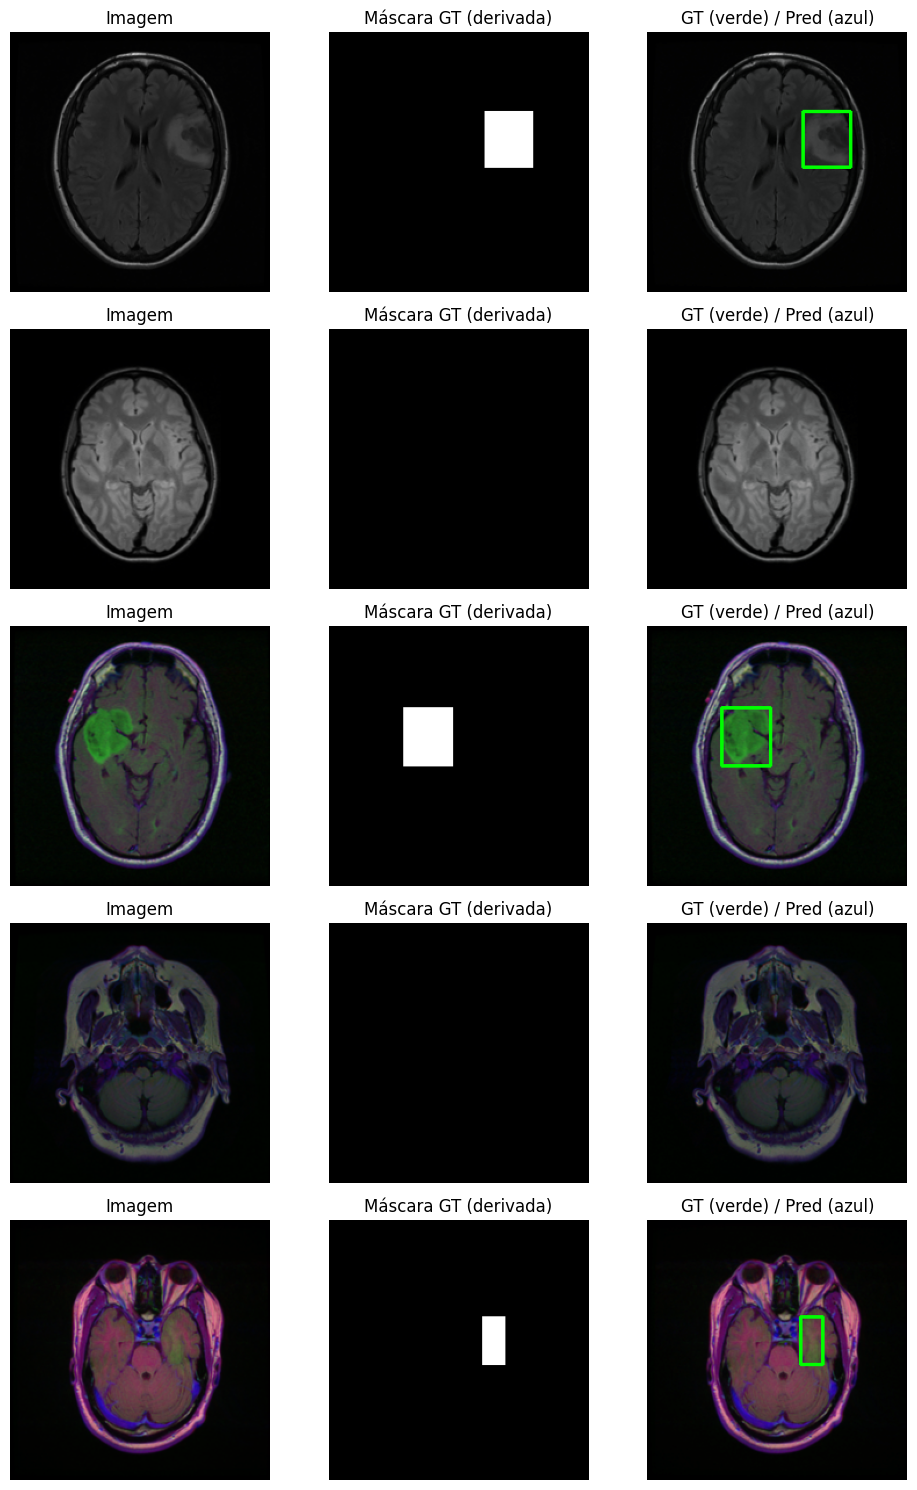

In [ ]:



!pip -q install kagglehub==0.3.4 timm==1.0.9 torchmetrics==1.4.0.post0 opencv-python==4.10.0.84


# Imports

import os, sys, math, glob, random, time
from pathlib import Path
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms as T
from torchmetrics.classification import BinaryPrecision, BinaryRecall
import matplotlib.pyplot as plt
import kagglehub


SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# Baixa o dataset do Kaggle

path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")
print("Path to dataset files:", path)
DATA_ROOT = Path(path)


# Clonar dinov3 e baixar o checkpoint .pth solicitado

%cd /content
if not Path("dinov3").exists():
    !git clone -q https://github.com/facebookresearch/dinov3.git

# Mesmo checkpoint ViT-S/16 (LVD-1689M) do seu script
ckpt_url = "https://dinov3.llamameta.net/dinov3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoiZWxyc2c2YzU3eGhpMXVqejV5bDdxNmhiIiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3NTgxNTE0ODJ9fX1dfQ__&Signature=ssy7icAYEwZK1hFKSy4f7yp6vnK6X3vaCeUbjebGmS4aP-R--RypCIR3uksrctJ05%7ENJYseSFOvuLTX8sYUFdF1Z7xF0BURQxBb4-kHWWidc9-gMBXHYGJwW825E4lyAE3uhzsyFHRjDOToz3WXXWXCHswfDRqhp6%7ExLPsJJUDJfDsTtENDUa23fOxFSvKZgHZPSDd%7ElIZRJHidG54i%7E9QtKceEAynca--nX2xaQqLFt1OriyZo99JuZ9JeXLEDb-ZXGJjcHRqtbJZS50gNoToj6qsxY7k72OkbvjQcnJhTWY8eF2k0NiqDBXr8B3u3HuRMgJg%7Et%7EoNpfW7qH7HxfA__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=772110548749499"
ckpt_path = "/content/dinov3_vits16_pretrain_lvd1689m-08c60483.pth"
if not Path(ckpt_path).exists():
    !wget -q --content-disposition -O "{ckpt_path}" "{ckpt_url}"
print("Checkpoint .pth em:", ckpt_path)


# Listar pares (imagem, máscara)

def find_image_mask_pairs(root: Path):
    img_exts = {".png",".jpg",".jpeg",".tif",".tiff"}
    all_imgs = [p for p in root.rglob("*") if p.suffix.lower() in img_exts and ("mask" not in p.stem.lower())]
    pairs = []
    for img in all_imgs:
        stem = img.stem
        cand = list(img.parent.glob(stem + "_mask.*"))
        if not cand:
            cand = [p for p in img.parent.glob("*") if ("mask" in p.stem.lower()) and p.suffix.lower() in img_exts]
        if cand:
            pairs.append((img, cand[0]))
    return pairs

pairs = find_image_mask_pairs(DATA_ROOT)
print(f"Total de pares encontrados: {len(pairs)}")
random.shuffle(pairs)


# Dataset e Transforms (torchvision puro) — DETECÇÃO

IMG_SIZE = 224  # múltiplo de 16 => grid 14x14 (evita reshape 13x13)
IMG_PATCH = 16
GRID = IMG_SIZE // IMG_PATCH   # 14
STRIDE = IMG_PATCH

mean = (0.485, 0.456, 0.406); std = (0.229, 0.224, 0.225)

train_tf = T.Compose([
    T.ToTensor(),
    T.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    T.ConvertImageDtype(torch.float32),
    T.Normalize(mean, std),
])
val_tf = T.Compose([
    T.ToTensor(),
    T.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    T.ConvertImageDtype(torch.float32),
    T.Normalize(mean, std),
])

def apply_simple_aug(img, mask):
    # Flip horizontal 50%
    if random.random() < 0.5:
        img  = np.ascontiguousarray(np.fliplr(img))
        mask = np.ascontiguousarray(np.fliplr(mask))
    # Jitter leve brilho/contraste na imagem
    if random.random() < 0.2:
        alpha = 1.0 + random.uniform(-0.2, 0.2)  # contraste
        beta  = random.uniform(-20, 20)          # brilho
        img = np.clip(alpha*img + beta, 0, 255).astype(np.uint8)
    return img, mask

# --- util: máscara binária -> lista de caixas [x1,y1,x2,y2] em coords 224x224 ---
def mask_to_boxes(mask_np, min_area=10):
    cnts, _ = cv2.findContours((mask_np>0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in cnts:
        x,y,w,h = cv2.boundingRect(c)
        if w*h >= min_area:
            x1,y1,x2,y2 = x, y, x+w, y+h
            boxes.append([x1,y1,x2,y2])
    return boxes

class MRIDetDataset(Dataset):
    def __init__(self, pairs, img_transform, is_train=False):
        self.pairs = pairs
        self.img_transform = img_transform
        self.is_train = is_train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, msk_path = self.pairs[idx]
        img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if img is None: raise RuntimeError(f"Falha ao ler imagem: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(msk_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            img_maybe = cv2.imread(str(msk_path), cv2.IMREAD_COLOR)
            if img_maybe is None: raise RuntimeError(f"Falha ao ler máscara: {msk_path}")
            mask = cv2.cvtColor(img_maybe, cv2.COLOR_BGR2GRAY)

        _, mask = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY)

        if self.is_train:
            img, mask = apply_simple_aug(img, mask)

        img_res  = cv2.resize(img,  (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        mask_res = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        boxes = mask_to_boxes(mask_res, min_area=10)  # uma ou mais caixas
        img_t = (train_tf if self.is_train else val_tf)(img_res)

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),    # [N,4] (x1,y1,x2,y2)
            "labels": torch.ones((len(boxes),), dtype=torch.long) # tudo classe 1
        }
        return img_t, target

# Split 80/10/10
n_total = len(pairs)
n_train = int(0.8 * n_total); n_val = int(0.1 * n_total); n_test = n_total - n_train - n_val
ds_train = MRIDetDataset(pairs[:n_train], img_transform=train_tf, is_train=True)
ds_val   = MRIDetDataset(pairs[n_train:n_train+n_val], img_transform=val_tf, is_train=False)
ds_test  = MRIDetDataset(pairs[n_train+n_val:], img_transform=val_tf, is_train=False)

def collate_det(batch):
    imgs, targets = zip(*batch)
    return torch.stack(imgs,0), list(targets)

batch_size = 8
train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True, drop_last=True, collate_fn=collate_det)
val_loader   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True, collate_fn=collate_det)
test_loader  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True, collate_fn=collate_det)
print(f"#itens: train={len(ds_train)} val={len(ds_val)} test={len(ds_test)}")


# Carregar ViT-S/16 via PyTorch Hub (local) — extração robusta de PATCH TOKENS

REPO_DIR = "/content/dinov3"
dinov3_vits16 = torch.hub.load(
    REPO_DIR,
    'dinov3_vits16',
    source='local',
    weights=ckpt_path
).to(device).eval()

def _pick_best_tensor(candidates, img_size=IMG_SIZE, patch=IMG_PATCH):
    """Escolhe o tensor de patches: [B,N(+1),C] ou [B,C,H',W'] com H'*W'≈grid."""
    grid = (img_size // patch) * (img_size // patch)
    for t in candidates:
        if not torch.is_tensor(t): continue
        if t.ndim == 3:
            B, N, C = t.shape
            if N in (grid, grid+1) and C >= 128:
                return t
    for t in candidates:
        if not torch.is_tensor(t): continue
        if t.ndim == 4:
            B, C, H, W = t.shape
            if H * W == grid and C >= 128:
                return t
    return None

def _collect_forward_tensors(m, x):
    """Roda um forward com hooks e coleta saídas candidatas."""
    candidates = []
    handles = []
    def hook(_, __, out):
        if torch.is_tensor(out):
            candidates.append(out)
        elif isinstance(out, (list, tuple)):
            candidates.extend([t for t in out if torch.is_tensor(t)])
        elif isinstance(out, dict):
            candidates.extend([v for v in out.values() if torch.is_tensor(v)])
    for sub in m.modules():
        try:
            h = sub.register_forward_hook(hook)
            handles.append(h)
        except: pass
    with torch.inference_mode():
        _ = m(x)
    for h in handles:
        try: h.remove()
        except: pass
    return candidates

def extract_patch_tokens(backbone, x, img_size=IMG_SIZE, patch=IMG_PATCH):
    """Retorna feature map [B,C,H',W'] (H'=W'=IMG_SIZE/patch)."""
    grid = (img_size // patch) * (img_size // patch)
    with torch.inference_mode():
        if hasattr(backbone, "get_intermediate_layers"):
            try:
                outs = backbone.get_intermediate_layers(x, n=1, return_class_token=True)
            except TypeError:
                try: outs = backbone.get_intermediate_layers(x, 1, True)
                except TypeError: outs = backbone.get_intermediate_layers(x, 1)
            if isinstance(outs, (list, tuple)):
                z = next((t for t in outs if torch.is_tensor(t) and t.ndim in (3,4)), None)
                if z is not None:
                    if z.ndim == 4:
                        return z
                    B, N, C = z.shape
                    if N == grid + 1: z = z[:, 1:, :]
                    h = w = img_size // patch
                    return z.transpose(1, 2).reshape(B, C, h, w).contiguous()
        if hasattr(backbone, "forward_features"):
            feat = backbone.forward_features(x)
            pool = []
            if torch.is_tensor(feat): pool = [feat]
            elif isinstance(feat, (list, tuple)): pool = [t for t in feat if torch.is_tensor(t)]
            elif isinstance(feat, dict): pool = [v for v in feat.values() if torch.is_tensor(v)]
            z = _pick_best_tensor(pool, img_size, patch)
            if z is not None:
                if z.ndim == 4: return z
                B, N, C = z.shape
                if N == grid + 1: z = z[:, 1:, :]
                h = w = img_size // patch
                return z.transpose(1, 2).reshape(B, C, h, w).contiguous()
        cands = _collect_forward_tensors(backbone, x)
        z = _pick_best_tensor(cands, img_size, patch)
        if z is None:
            only_bc = any(torch.is_tensor(t) and t.ndim == 2 for t in cands)
            if only_bc:
                raise RuntimeError("O hub devolveu apenas embeddings globais [B,C] e nenhum tensor [B,N,C] ou [B,C,H',W'].")
            raise RuntimeError("Não foi possível localizar tokens/feature map nos intermediários do backbone.")
        if z.ndim == 4:
            return z
        B, N, C = z.shape
        if N == grid + 1: z = z[:, 1:, :]
        h = w = img_size // patch
        return z.transpose(1, 2).reshape(B, C, h, w).contiguous()

# Wrapper para usar no modelo
class DinoV3FeatureExtractor(nn.Module):
    def __init__(self, backbone, img_size=IMG_SIZE, patch=IMG_PATCH):
        super().__init__()
        self.backbone = backbone
        self.img_size = img_size
        self.patch = patch
    def forward(self, x):
        return extract_patch_tokens(self.backbone, x, self.img_size, self.patch)

# Descobrir embed_dim de forma automática
with torch.no_grad():
    xb, _ = next(iter(train_loader))
    xb = xb.to(device)
    fmap = extract_patch_tokens(dinov3_vits16, xb, img_size=IMG_SIZE, patch=IMG_PATCH)  # [B,C,14,14] para 224
embed_dim = fmap.shape[1]
print("Feature map inicial:", tuple(fmap.shape), "embed_dim:", embed_dim)

feat_extractor = DinoV3FeatureExtractor(dinov3_vits16, img_size=IMG_SIZE, patch=IMG_PATCH).to(device)


# Head leve de detecção anchor-free (heatmap + box LTRB)

def cell_center(i, j, stride=STRIDE):
    y = i*stride + stride/2.0
    x = j*stride + stride/2.0
    return x, y

class DetHead(nn.Module):
    def __init__(self, in_ch, out_classes=1, hidden=256):
        super().__init__()
        self.up1 = nn.Sequential(
            nn.Conv2d(in_ch, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden),
            nn.ReLU(inplace=True)
        )
        self.heatmap = nn.Conv2d(hidden, out_classes, 1)  # logits
        self.box     = nn.Conv2d(hidden, 4, 1)           # l,t,r,b
        nn.init.constant_(self.heatmap.bias, -2.0)       # poucos positivos no início
    def forward(self, f):
        h = self.up1(f)
        return self.heatmap(h), self.box(h)

class DetModel(nn.Module):
    def __init__(self, feat_extractor, in_ch):
        super().__init__()
        self.backbone = feat_extractor
        self.decoder  = DetHead(in_ch, out_classes=1, hidden=256)
    def forward(self, x):
        with torch.no_grad():
            f = self.backbone(x)      # [B,C,14,14]
        hm, box = self.decoder(f)     # hm:[B,1,14,14], box:[B,4,14,14]
        return hm, box

model = DetModel(feat_extractor, in_ch=embed_dim).to(device)


# Perdas, otimizador e métricas

def focal_loss(inputs, targets, alpha=0.25, gamma=2.0, eps=1e-6):
    # inputs: logits [B,1,H,W]; targets: {0,1} mesma shape
    p  = torch.sigmoid(inputs)
    pt = p*targets + (1-p)*(1-targets)
    w  = alpha*targets + (1-alpha)*(1-targets)
    return (-w * (1-pt).pow(gamma) * torch.log(pt.clamp_min(eps))).mean()

# "iou" e "dice" serão usados como nomes apenas para manter a interface:
# aqui representam Precision e Recall, respectivamente, no heatmap.
metric_prec = BinaryPrecision().to(device)
metric_rec  = BinaryRecall().to(device)

optimizer = torch.optim.AdamW(model.decoder.parameters(), lr=1e-3, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))

def build_targets(batch_targets):
    """Retorna heatmap alvo e box alvo (apenas nas células positivas)."""
    B = len(batch_targets)
    hm_t    = torch.zeros((B,1,GRID,GRID), dtype=torch.float32, device=device)
    posmask = torch.zeros_like(hm_t)
    box_t   = torch.zeros((B,4,GRID,GRID), dtype=torch.float32, device=device)
    for b, tgt in enumerate(batch_targets):
        if len(tgt["boxes"]) == 0:
            continue
        for (x1,y1,x2,y2) in tgt["boxes"].tolist():
            cx, cy = (x1+x2)/2.0, (y1+y2)/2.0
            j = int(cx // STRIDE)  # col
            i = int(cy // STRIDE)  # lin
            if i<0 or j<0 or i>=GRID or j>=GRID:
                continue
            ccx, ccy = cell_center(i,j)
            l = max(0.0, ccx - x1)
            t = max(0.0, ccy - y1)
            r = max(0.0, x2 - ccx)
            b_ = max(0.0, y2 - ccy)
            hm_t[b,0,i,j] = 1.0
            posmask[b,0,i,j] = 1.0
            box_t[b,:,i,j] = torch.tensor([l,t,r,b_], device=device)
    return hm_t, posmask, box_t


# Loop de treino/val

def run_epoch(loader, model, optimizer=None, thr=0.3, lam_l1=1.0):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    running_loss = running_prec = running_rec = 0.0
    n_batches = 0

    for xb, tgt_list in loader:
        xb = xb.to(device, non_blocking=True)
        hm_t, posmask, box_t = build_targets(tgt_list)

        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            hm, box = model(xb)
            lf = focal_loss(hm, hm_t)
            l1 = torch.abs(box - box_t) * posmask
            l1 = l1.sum() / (posmask.sum().clamp(min=1.0))
            loss = lf + lam_l1*l1

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        # métricas: Precision/Recall no heatmap (threshold fixo)
        with torch.no_grad():
            pred_bin = (torch.sigmoid(hm) > thr).to(torch.int)
            targ_bin = (hm_t > 0.5).to(torch.int)
            # flatten para torchmetrics
            pb = pred_bin.view(-1).to(device)
            tb = targ_bin.view(-1).to(device)
            prec = metric_prec(pb, tb).item()
            rec  = metric_rec(pb, tb).item()

        running_loss += loss.item(); running_prec += prec; running_rec += rec; n_batches += 1

    return running_loss/n_batches, running_prec/n_batches, running_rec/n_batches

EPOCHS = 50
best_val = 0.0
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_iou, tr_dice = run_epoch(train_loader, model, optimizer, thr=0.3)   # iou->Precision, dice->Recall
    with torch.no_grad():
        va_loss, va_iou, va_dice = run_epoch(val_loader, model, optimizer=None, thr=0.3)
    print(f"[{epoch:02d}/{EPOCHS}] "
          f"train_loss={tr_loss:.4f} Precision={tr_iou:.4f} Recall={tr_dice:.4f} | "
          f"val_loss={va_loss:.4f} Precision={va_iou:.4f} Recall={va_dice:.4f} | {time.time()-t0:.1f}s")
    if va_dice > best_val:  # usando Recall como critério
        best_val = va_dice
        torch.save(model.state_dict(), "/content/dinov3_vits16_lgg_det_best.pt")

print("Treino finalizado. Melhor Recall (val):", best_val)


# Avaliação no teste + Visualização

with torch.no_grad():
    te_loss, te_iou, te_dice = run_epoch(test_loader, model, optimizer=None, thr=0.3)
print(f"[TEST] loss={te_loss:.4f} Precision={te_iou:.4f} Recall={te_dice:.4f}")

# Decodificação + NMS para visualização (GT verde / Pred azul) ----
def decode_topk(hm, box, k=50, thr=0.3):
    p = torch.sigmoid(hm)[0,0]  # [14,14]
    b = box[0]                  # [4,14,14]
    scores = []
    for i in range(GRID):
        for j in range(GRID):
            s = p[i,j].item()
            if s < thr: continue
            ccx, ccy = cell_center(i,j)
            l,t,r,bb = b[:,i,j].tolist()
            x1,y1 = ccx - l, ccy - t
            x2,y2 = ccx + r, ccy + bb
            x1,y1 = max(0,x1), max(0,y1)
            x2,y2 = min(IMG_SIZE,x2), min(IMG_SIZE,y2)
            if x2>x1 and y2>y1:
                scores.append((s, x1,y1,x2,y2))
    scores.sort(key=lambda x: x[0], reverse=True)
    return scores[:k]

def nms(boxes, iou_thr=0.5):
    out = []
    boxes = boxes[:]
    while boxes:
        best = boxes.pop(0)
        out.append(best)
        keep = []
        ax1,ay1,ax2,ay2 = best[1:]
        a = (ax2-ax1)*(ay2-ay1)
        for cand in boxes:
            bx1,by1,bx2,by2 = cand[1:]
            inter = max(0, min(ax2,bx2)-max(ax1,bx1)) * max(0, min(ay2,by2)-max(ay1,by1))
            b = (bx2-bx1)*(by2-by1)
            iou = inter / (a+b-inter+1e-6)
            if iou <= iou_thr: keep.append(cand)
        boxes = keep
    return out

def show_examples(loader, model, k=5, score_thr=0.3, iou_thr=0.5):
    model.eval()
    xb_all, tgt_all = next(iter(loader))
    xb_all = xb_all.to(device)
    with torch.no_grad():
        hm, box = model(xb_all)
    # desnormaliza p/ visualização
    std = np.array((0.229, 0.224, 0.225)); mean = np.array((0.485, 0.456, 0.406))
    xb_np = xb_all.cpu().numpy().transpose(0,2,3,1)
    xb_vis = xb_np * std[None,None,None,:] + mean[None,None,None,:]
    xb_vis = np.clip(xb_vis, 0.0, 1.0)

    rows = min(k, xb_vis.shape[0])
    plt.figure(figsize=(10, 3*rows))
    for i in range(rows):
        preds = decode_topk(hm[i:i+1], box[i:i+1], k=50, thr=score_thr)
        preds = nms(preds, iou_thr=iou_thr)
        vis = (xb_vis[i]*255).astype(np.uint8).copy()
        # GT
        for (x1,y1,x2,y2) in tgt_all[i]["boxes"].numpy():
            cv2.rectangle(vis, (int(x1),int(y1)), (int(x2),int(y2)), (0,255,0), 2)
        # Preds
        for s,x1,y1,x2,y2 in preds:
            cv2.rectangle(vis, (int(x1),int(y1)), (int(x2),int(y2)), (255,0,0), 2)
            cv2.putText(vis, f"{s:.2f}", (int(x1),max(0,int(y1)-3)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,0,0), 1)
        plt.subplot(rows,3,3*i+1); plt.imshow(xb_vis[i]); plt.axis('off'); plt.title("Imagem")
        # Máscara GT (opcional: desenhar preenchida)
        m = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        for (x1,y1,x2,y2) in tgt_all[i]["boxes"].numpy():
            cv2.rectangle(m, (int(x1),int(y1)), (int(x2),int(y2)), 255, -1)
        plt.subplot(rows,3,3*i+2); plt.imshow(m, cmap='gray'); plt.axis('off'); plt.title("Máscara GT (derivada)")
        plt.subplot(rows,3,3*i+3); plt.imshow(vis); plt.axis('off'); plt.title("GT (verde) / Pred (azul)")
    plt.tight_layout(); plt.show()

# Visualização
show_examples(test_loader, model, k=5, score_thr=0.3, iou_thr=0.5)


## DINOv3 ViT-S/16 (PyTorch Hub) + Detecção
# Descongelando apenas os ÚLTIMOS BLOCOS do DINOv3


Device: cuda
Path to dataset files: /kaggle/input/lgg-mri-segmentation
/content
Checkpoint .pth em: /content/dinov3_vits16_pretrain_lvd1689m-08c60483.pth
Total de pares encontrados: 7858
[DET] train=6286 val=785 test=787
Feature map: (8, 384, 14, 14) embed_dim: 384


/tmp/ipython-input-1017406933.py:371: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))
/tmp/ipython-input-1017406933.py:409: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


[01/50] train_loss=26.4354 Precision=0.0080 Recall=0.0072 | val_loss=21.6916 Precision=0.0000 Recall=0.0000 | 64.8s
[02/50] train_loss=20.8143 Precision=0.0575 Recall=0.0570 | val_loss=19.7124 Precision=0.0387 Recall=0.0314 | 64.5s
[03/50] train_loss=18.6870 Precision=0.0928 Recall=0.0860 | val_loss=18.9938 Precision=0.0464 Recall=0.0695 | 64.4s
[04/50] train_loss=17.4897 Precision=0.1587 Recall=0.1539 | val_loss=17.9290 Precision=0.2219 Recall=0.3277 | 64.5s
[05/50] train_loss=15.5467 Precision=0.1071 Recall=0.1101 | val_loss=16.3470 Precision=0.0000 Recall=0.0000 | 63.7s
[06/50] train_loss=14.7354 Precision=0.2336 Recall=0.2223 | val_loss=16.4629 Precision=0.1397 Recall=0.0888 | 64.4s
[07/50] train_loss=13.9731 Precision=0.2021 Recall=0.1975 | val_loss=15.4308 Precision=0.0000 Recall=0.0000 | 64.7s
[08/50] train_loss=12.9988 Precision=0.2218 Recall=0.2252 | val_loss=14.7139 Precision=0.0993 Recall=0.0582 | 63.8s
[09/50] train_loss=12.4230 Precision=0.2131 Recall=0.2105 | val_loss=14.

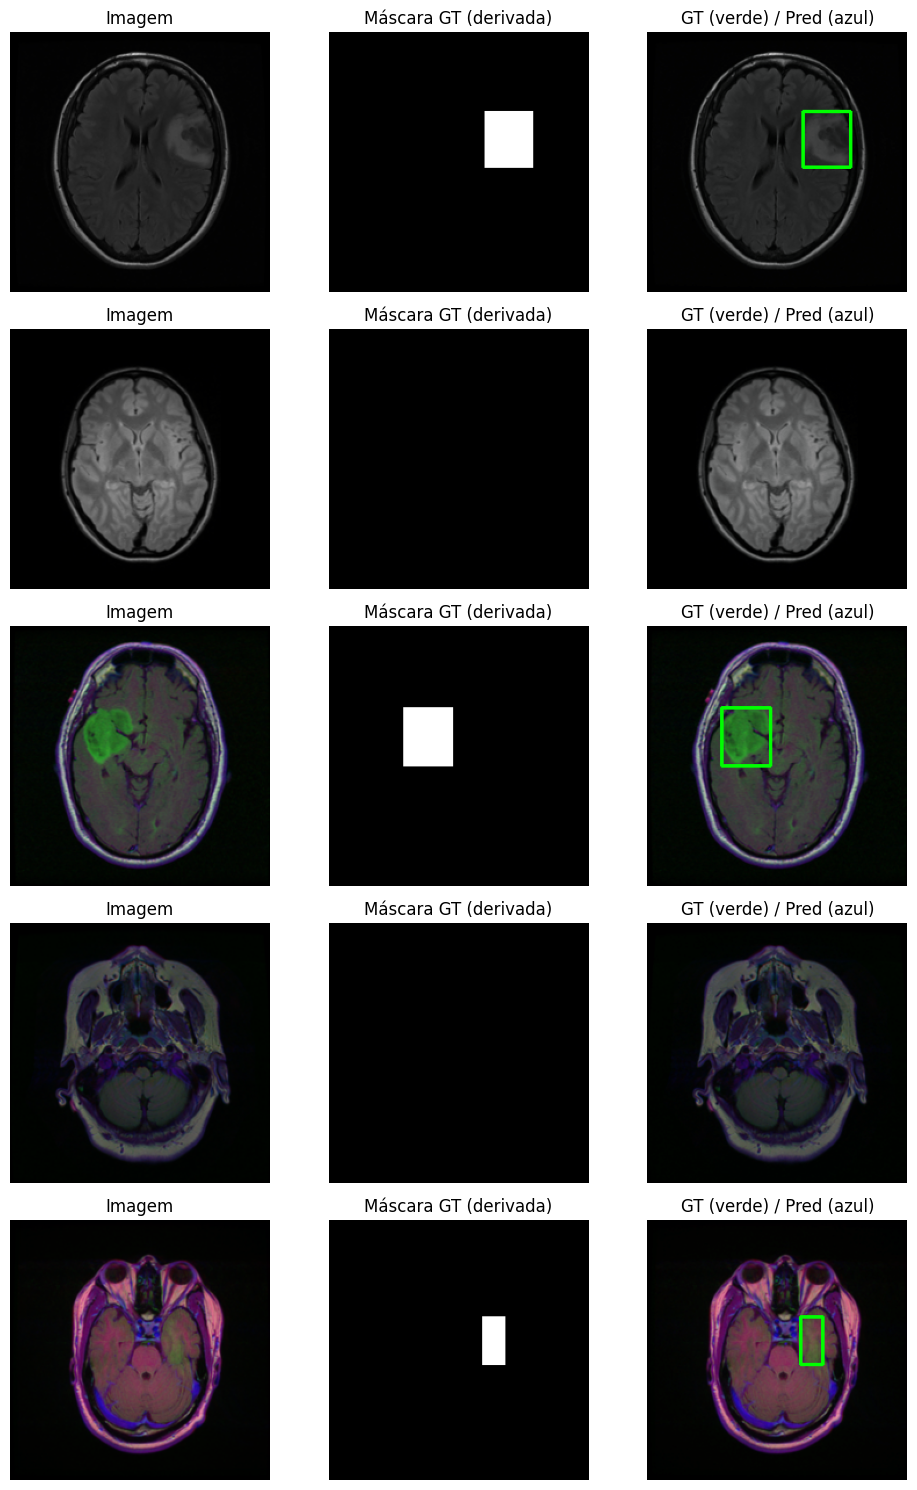

In [ ]:


!pip -q install kagglehub==0.3.4 timm==1.0.9 torchmetrics==1.4.0.post0 opencv-python==4.10.0.84


import os, sys, math, glob, random, time
from pathlib import Path
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms as T
from torchmetrics.classification import BinaryPrecision, BinaryRecall
import matplotlib.pyplot as plt
import kagglehub
from contextlib import nullcontext


SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# Hiperparâmetros de finetuning do backbone

TRAIN_BACKBONE = True          # True => vai descongelar os últimos blocos selecionados
UNFREEZE_N_BLOCKS = 2          # quantos blocos finais do ViT descongelar (1 ou 2)
UNFREEZE_LAYERNORM = True      # também descongelar todas as LayerNorms
HEAD_LR = 1e-3                 # LR do head de detecção
BACKBONE_LR = 1e-5             # LR menor para o backbone
BACKBONE_WD = 1e-5             # WD do backbone (leve)


# Baixa o dataset do Kaggle (LGG MRI)

path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")
print("Path to dataset files:", path)
DATA_ROOT = Path(path)


# Clonar dinov3 e baixar o checkpoint .pth solicitado

%cd /content
if not Path("dinov3").exists():
    !git clone -q https://github.com/facebookresearch/dinov3.git

# Mesmo checkpoint ViT-S/16 (LVD-1689M)
ckpt_url = "https://dinov3.llamameta.net/dinov3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoiZWxyc2c2YzU3eGhpMXVqejV5bDdxNmhiIiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3NTgxNTE0ODJ9fX1dfQ__&Signature=ssy7icAYEwZK1hFKSy4f7yp6vnK6X3vaCeUbjebGmS4aP-R--RypCIR3uksrctJ05%7ENJYseSFOvuLTX8sYUFdF1Z7xF0BURQxBb4-kHWWidc9-gMBXHYGJwW825E4lyAE3uhzsyFHRjDOToz3WXXWXCHswfDRqhp6%7ExLPsJJUDJfDsTtENDUa23fOxFSvKZgHZPSDd%7ElIZRJHidG54i%7E9QtKceEAynca--nX2xaQqLFt1OriyZo99JuZ9JeXLEDb-ZXGJjcHRqtbJZS50gNoToj6qsxY7k72OkbvjQcnJhTWY8eF2k0NiqDBXr8B3u3HuRMgJg%7Et%7EoNpfW7qH7HxfA__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=772110548749499"
ckpt_path = "/content/dinov3_vits16_pretrain_lvd1689m-08c60483.pth"
if not Path(ckpt_path).exists():
    !wget -q --content-disposition -O "{ckpt_path}" "{ckpt_url}"
print("Checkpoint .pth em:", ckpt_path)


# Listar pares (imagem, máscara)

def find_image_mask_pairs(root: Path):
    img_exts = {".png",".jpg",".jpeg",".tif",".tiff"}
    all_imgs = [p for p in root.rglob("*") if p.suffix.lower() in img_exts and ("mask" not in p.stem.lower())]
    pairs = []
    for img in all_imgs:
        stem = img.stem
        cand = list(img.parent.glob(stem + "_mask.*"))
        if not cand:
            cand = [p for p in img.parent.glob("*") if ("mask" in p.stem.lower()) and p.suffix.lower() in img_exts]
        if cand:
            pairs.append((img, cand[0]))
    return pairs

pairs = find_image_mask_pairs(DATA_ROOT)
print(f"Total de pares encontrados: {len(pairs)}")
random.shuffle(pairs)


# Dataset e Transforms (torchvision puro) — DETECÇÃO

IMG_SIZE = 224  # múltiplo de 16 => grid 14x14
IMG_PATCH = 16
GRID = IMG_SIZE // IMG_PATCH   # 14
STRIDE = IMG_PATCH

mean = (0.485, 0.456, 0.406); std = (0.229, 0.224, 0.225)

train_tf = T.Compose([
    T.ToTensor(),
    T.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    T.ConvertImageDtype(torch.float32),
    T.Normalize(mean, std),
])
val_tf = T.Compose([
    T.ToTensor(),
    T.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    T.ConvertImageDtype(torch.float32),
    T.Normalize(mean, std),
])

def apply_simple_aug(img, mask):
    if random.random() < 0.5:
        img  = np.ascontiguousarray(np.fliplr(img))
        mask = np.ascontiguousarray(np.fliplr(mask))
    if random.random() < 0.2:
        alpha = 1.0 + random.uniform(-0.2, 0.2)
        beta  = random.uniform(-20, 20)
        img = np.clip(alpha*img + beta, 0, 255).astype(np.uint8)
    return img, mask

def mask_to_boxes(mask_np, min_area=10):
    cnts, _ = cv2.findContours((mask_np>0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in cnts:
        x,y,w,h = cv2.boundingRect(c)
        if w*h >= min_area:
            x1,y1,x2,y2 = x, y, x+w, y+h
            boxes.append([x1,y1,x2,y2])
    return boxes

class MRIDetDataset(Dataset):
    def __init__(self, pairs, img_transform, is_train=False):
        self.pairs = pairs
        self.img_transform = img_transform
        self.is_train = is_train
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        img_path, msk_path = self.pairs[idx]
        img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if img is None: raise RuntimeError(f"Falha ao ler imagem: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(msk_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            img_maybe = cv2.imread(str(msk_path), cv2.IMREAD_COLOR)
            if img_maybe is None: raise RuntimeError(f"Falha ao ler máscara: {msk_path}")
            mask = cv2.cvtColor(img_maybe, cv2.COLOR_BGR2GRAY)

        _, mask = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY)

        if self.is_train:
            img, mask = apply_simple_aug(img, mask)

        img_res  = cv2.resize(img,  (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        mask_res = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        boxes = mask_to_boxes(mask_res, min_area=10)
        img_t = (train_tf if self.is_train else val_tf)(img_res)

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.ones((len(boxes),), dtype=torch.long)
        }
        return img_t, target

# Split 80/10/10
n_total = len(pairs)
n_train = int(0.8 * n_total); n_val = int(0.1 * n_total); n_test = n_total - n_train - n_val
ds_train = MRIDetDataset(pairs[:n_train], img_transform=train_tf, is_train=True)
ds_val   = MRIDetDataset(pairs[n_train:n_train+n_val], img_transform=val_tf, is_train=False)
ds_test  = MRIDetDataset(pairs[n_train+n_val:], img_transform=val_tf, is_train=False)

def collate_det(batch):
    imgs, targets = zip(*batch)
    return torch.stack(imgs,0), list(targets)

batch_size = 8
train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True,  num_workers=2,
                          pin_memory=True, drop_last=True, collate_fn=collate_det)
val_loader   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=2,
                          pin_memory=True, collate_fn=collate_det)
test_loader  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False, num_workers=2,
                          pin_memory=True, collate_fn=collate_det)
print(f"[DET] train={len(ds_train)} val={len(ds_val)} test={len(ds_test)}")


# Carregar ViT-S/16 (Hub) + descongelar últimos blocos

REPO_DIR = "/content/dinov3"
dinov3_vits16 = torch.hub.load(
    REPO_DIR, 'dinov3_vits16', source='local', weights=ckpt_path
).to(device)

# Congela tudo inicialmente
for p in dinov3_vits16.parameters():
    p.requires_grad = False

# Tenta localizar os blocos Transformer
blocks = getattr(dinov3_vits16, "blocks", None)
if blocks is None and hasattr(dinov3_vits16, "encoder"):
    blocks = getattr(dinov3_vits16.encoder, "blocks", None)

# Descongela somente os últimos N blocos
if TRAIN_BACKBONE and blocks is not None and len(blocks) > 0:
    for b in list(blocks)[-UNFREEZE_N_BLOCKS:]:
        for p in b.parameters():
            p.requires_grad = True

# (Opcional) Descongelar todas as LayerNorms (adaptação suave)
if TRAIN_BACKBONE and UNFREEZE_LAYERNORM:
    for m in dinov3_vits16.modules():
        if isinstance(m, nn.LayerNorm):
            for p in m.parameters():
                p.requires_grad = True

# Define modo train/eval do backbone conforme haja algo treinável
if TRAIN_BACKBONE and any(p.requires_grad for p in dinov3_vits16.parameters()):
    dinov3_vits16.train()
else:
    dinov3_vits16.eval()


# Extração robusta de PATCH TOKENS (com suporte a gradiente)

def _pick_best_tensor(candidates, img_size=224, patch=16):
    grid = (img_size // patch) * (img_size // patch)
    for t in candidates:
        if torch.is_tensor(t) and t.ndim == 3:
            B, N, C = t.shape
            if N in (grid, grid+1) and C >= 128:
                return t
    for t in candidates:
        if torch.is_tensor(t) and t.ndim == 4:
            B, C, H, W = t.shape
            if H * W == grid and C >= 128:
                return t
    return None

def _collect_forward_tensors(m, x, requires_grad=False):
    candidates, handles = [], []
    def hook(_, __, out):
        if torch.is_tensor(out): candidates.append(out)
        elif isinstance(out, (list, tuple)):
            candidates.extend([t for t in out if torch.is_tensor(t)])
        elif isinstance(out, dict):
            candidates.extend([v for v in out.values() if torch.is_tensor(v)])
    for sub in m.modules():
        try:
            h = sub.register_forward_hook(hook); handles.append(h)
        except: pass
    ctx = nullcontext() if requires_grad else torch.inference_mode()
    with ctx:
        _ = m(x)
    for h in handles:
        try: h.remove()
        except: pass
    return candidates

def extract_patch_tokens(backbone, x, img_size=224, patch=16, requires_grad=False):
    grid = (img_size // patch) * (img_size // patch)
    ctx = nullcontext() if requires_grad else torch.inference_mode()
    with ctx:
        if hasattr(backbone, "get_intermediate_layers"):
            try:
                outs = backbone.get_intermediate_layers(x, n=1, return_class_token=True)
            except TypeError:
                try: outs = backbone.get_intermediate_layers(x, 1, True)
                except TypeError: outs = backbone.get_intermediate_layers(x, 1)
            if isinstance(outs, (list, tuple)):
                z = next((t for t in outs if torch.is_tensor(t) and t.ndim in (3,4)), None)
                if z is not None:
                    if z.ndim == 4: return z
                    B, N, C = z.shape
                    if N == grid + 1: z = z[:, 1:, :]
                    h = w = img_size // patch
                    return z.transpose(1, 2).reshape(B, C, h, w).contiguous()
        if hasattr(backbone, "forward_features"):
            feat = backbone.forward_features(x)
            pool = []
            if torch.is_tensor(feat): pool = [feat]
            elif isinstance(feat, (list, tuple)): pool = [t for t in feat if torch.is_tensor(t)]
            elif isinstance(feat, dict): pool = [v for v in feat.values() if torch.is_tensor(v)]
            z = _pick_best_tensor(pool, img_size, patch)
            if z is not None:
                if z.ndim == 4: return z
                B, N, C = z.shape
                if N == grid + 1: z = z[:, 1:, :]
                h = w = img_size // patch
                return z.transpose(1, 2).reshape(B, C, h, w).contiguous()
        cands = _collect_forward_tensors(backbone, x, requires_grad=requires_grad)
        z = _pick_best_tensor(cands, img_size, patch)
        if z is None:
            only_bc = any(torch.is_tensor(t) and t.ndim == 2 for t in cands)
            if only_bc: raise RuntimeError("Backbone gerou apenas embeddings globais [B,C].")
            raise RuntimeError("Não foi possível localizar tokens/feature map intermediário.")
        if z.ndim == 4: return z
        B, N, C = z.shape
        if N == grid + 1: z = z[:, 1:, :]
        h = w = img_size // patch
        return z.transpose(1, 2).reshape(B, C, h, w).contiguous()

class DinoV3FeatureExtractor(nn.Module):
    def __init__(self, backbone, img_size=IMG_SIZE, patch=IMG_PATCH, trainable=False):
        super().__init__()
        self.backbone = backbone
        self.img_size = img_size
        self.patch = patch
        self.trainable = trainable
    def forward(self, x):
        return extract_patch_tokens(
            self.backbone, x, self.img_size, self.patch,
            requires_grad=self.trainable
        )

# Descobrir embed_dim de forma automática
with torch.no_grad():
    xb, _ = next(iter(train_loader))
    xb = xb.to(device)
    fmap = extract_patch_tokens(dinov3_vits16, xb, img_size=IMG_SIZE, patch=IMG_PATCH, requires_grad=False)
embed_dim = fmap.shape[1]
print("Feature map:", tuple(fmap.shape), "embed_dim:", embed_dim)

feat_extractor = DinoV3FeatureExtractor(
    dinov3_vits16, img_size=IMG_SIZE, patch=IMG_PATCH, trainable=TRAIN_BACKBONE
).to(device)


# Head de detecção anchor-free (heatmap + box LTRB)

def cell_center(i, j, stride=STRIDE):
    y = i*stride + stride/2.0
    x = j*stride + stride/2.0
    return x, y

class DetHead(nn.Module):
    def __init__(self, in_ch, out_classes=1, hidden=256):
        super().__init__()
        self.up1 = nn.Sequential(
            nn.Conv2d(in_ch, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden),
            nn.ReLU(inplace=True)
        )
        self.heatmap = nn.Conv2d(hidden, out_classes, 1)  # logits
        self.box     = nn.Conv2d(hidden, 4, 1)           # l,t,r,b
        nn.init.constant_(self.heatmap.bias, -2.0)
    def forward(self, f):
        h = self.up1(f)
        return self.heatmap(h), self.box(h)

class DetModel(nn.Module):
    def __init__(self, feat_extractor, in_ch):
        super().__init__()
        self.backbone = feat_extractor
        self.decoder  = DetHead(in_ch, out_classes=1, hidden=256)
    def forward(self, x):
        f = self.backbone(x)            # agora com/sem grad conforme trainable
        hm, box = self.decoder(f)
        return hm, box

model = DetModel(feat_extractor, in_ch=embed_dim).to(device)


# Perdas, otimizador e métricas

def focal_loss(inputs, targets, alpha=0.25, gamma=2.0, eps=1e-6):
    p  = torch.sigmoid(inputs)
    pt = p*targets + (1-p)*(1-targets)
    w  = alpha*targets + (1-alpha)*(1-targets)
    return (-w * (1-pt).pow(gamma) * torch.log(pt.clamp_min(eps))).mean()

metric_prec = BinaryPrecision().to(device)
metric_rec  = BinaryRecall().to(device)

# Otimizador com dois grupos: head (LR maior) e backbone (LR menor)
backbone_trainable_params = [p for p in feat_extractor.backbone.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW([
    {"params": model.decoder.parameters(),    "lr": HEAD_LR,     "weight_decay": 1e-4},
    {"params": backbone_trainable_params,     "lr": BACKBONE_LR, "weight_decay": BACKBONE_WD},
])
scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))

def build_targets(batch_targets):
    B = len(batch_targets)
    hm_t    = torch.zeros((B,1,GRID,GRID), dtype=torch.float32, device=device)
    posmask = torch.zeros_like(hm_t)
    box_t   = torch.zeros((B,4,GRID,GRID), dtype=torch.float32, device=device)
    for b, tgt in enumerate(batch_targets):
        if len(tgt["boxes"]) == 0: continue
        for (x1,y1,x2,y2) in tgt["boxes"].tolist():
            cx, cy = (x1+x2)/2.0, (y1+y2)/2.0
            j = int(cx // STRIDE)
            i = int(cy // STRIDE)
            if i<0 or j<0 or i>=GRID or j>=GRID:
                continue
            ccx, ccy = cell_center(i,j)
            l = max(0.0, ccx - x1)
            t = max(0.0, ccy - y1)
            r = max(0.0, x2 - ccx)
            b_ = max(0.0, y2 - ccy)
            hm_t[b,0,i,j] = 1.0
            posmask[b,0,i,j] = 1.0
            box_t[b,:,i,j] = torch.tensor([l,t,r,b_], device=device)
    return hm_t, posmask, box_t


# Loop de treino/val

def run_epoch(loader, model, optimizer=None, thr=0.3, lam_l1=1.0):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    running_loss = running_prec = running_rec = 0.0
    n_batches = 0

    for xb, tgt_list in loader:
        xb = xb.to(device, non_blocking=True)
        hm_t, posmask, box_t = build_targets(tgt_list)

        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            hm, box = model(xb)
            lf = focal_loss(hm, hm_t)
            l1 = torch.abs(box - box_t) * posmask
            l1 = l1.sum() / (posmask.sum().clamp(min=1.0))
            loss = lf + lam_l1*l1

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            # (Opcional) estabilidade extra
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

        with torch.no_grad():
            pred_bin = (torch.sigmoid(hm) > thr).to(torch.int)
            targ_bin = (hm_t > 0.5).to(torch.int)
            pb = pred_bin.view(-1).to(device)
            tb = targ_bin.view(-1).to(device)
            prec = metric_prec(pb, tb).item()
            rec  = metric_rec(pb, tb).item()

        running_loss += loss.item(); running_prec += prec; running_rec += rec; n_batches += 1

    return running_loss/n_batches, running_prec/n_batches, running_rec/n_batches

EPOCHS = 50
best_val = 0.0
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_prec, tr_rec = run_epoch(train_loader, model, optimizer, thr=0.3)
    with torch.no_grad():
        va_loss, va_prec, va_rec = run_epoch(val_loader, model, optimizer=None, thr=0.3)
    print(f"[{epoch:02d}/{EPOCHS}] "
          f"train_loss={tr_loss:.4f} Precision={tr_prec:.4f} Recall={tr_rec:.4f} | "
          f"val_loss={va_loss:.4f} Precision={va_prec:.4f} Recall={va_rec:.4f} | {time.time()-t0:.1f}s")
    if va_rec > best_val:
        best_val = va_rec
        torch.save(model.state_dict(), "/content/dinov3_vits16_lgg_det_best.pt")

print("Detecção treinada. Melhor Recall (val):", best_val)


# Avaliação no teste + Visualização

with torch.no_grad():
    te_loss, te_prec, te_rec = run_epoch(test_loader, model, optimizer=None, thr=0.3)
print(f"[TEST] loss={te_loss:.4f} Precision={te_prec:.4f} Recall={te_rec:.4f}")

def decode_topk(hm, box, k=50, thr=0.3):
    p = torch.sigmoid(hm)[0,0]  # [14,14]
    b = box[0]                  # [4,14,14]
    scores = []
    for i in range(GRID):
        for j in range(GRID):
            s = p[i,j].item()
            if s < thr: continue
            ccx, ccy = cell_center(i,j)
            l,t,r,bb = b[:,i,j].tolist()
            x1,y1 = ccx - l, ccy - t
            x2,y2 = ccx + r, ccy + bb
            x1,y1 = max(0,x1), max(0,y1)
            x2,y2 = min(IMG_SIZE,x2), min(IMG_SIZE,y2)
            if x2>x1 and y2>y1:
                scores.append((s, x1,y1,x2,y2))
    scores.sort(key=lambda x: x[0], reverse=True)
    return scores[:k]

def nms(boxes, iou_thr=0.5):
    out = []
    boxes = boxes[:]
    while boxes:
        best = boxes.pop(0)
        out.append(best)
        keep = []
        ax1,ay1,ax2,ay2 = best[1:]
        a = (ax2-ax1)*(ay2-ay1)
        for cand in boxes:
            bx1,by1,bx2,by2 = cand[1:]
            inter = max(0, min(ax2,bx2)-max(ax1,bx1)) * max(0, min(ay2,by2)-max(ay1,by1))
            b = (bx2-bx1)*(by2-by1)
            iou = inter / (a+b-inter+1e-6)
            if iou <= iou_thr: keep.append(cand)
        boxes = keep
    return out

def show_examples(loader, model, k=5, score_thr=0.3, iou_thr=0.5):
    model.eval()
    xb_all, tgt_all = next(iter(loader))
    xb_all = xb_all.to(device)
    with torch.no_grad():
        hm, box = model(xb_all)
    std = np.array((0.229, 0.224, 0.225)); mean = np.array((0.485, 0.456, 0.406))
    xb_np = xb_all.cpu().numpy().transpose(0,2,3,1)
    xb_vis = xb_np * std[None,None,None,:] + mean[None,None,None,:]
    xb_vis = np.clip(xb_vis, 0.0, 1.0)

    rows = min(k, xb_vis.shape[0])
    plt.figure(figsize=(10, 3*rows))
    for i in range(rows):
        preds = decode_topk(hm[i:i+1], box[i:i+1], k=50, thr=score_thr)
        preds = nms(preds, iou_thr=iou_thr)
        vis = (xb_vis[i]*255).astype(np.uint8).copy()
        # GT (verde)
        for (x1,y1,x2,y2) in tgt_all[i]["boxes"].numpy():
            cv2.rectangle(vis, (int(x1),int(y1)), (int(x2),int(y2)), (0,255,0), 2)
        # Preds (azul)
        for s,x1,y1,x2,y2 in preds:
            cv2.rectangle(vis, (int(x1),int(y1)), (int(x2),int(y2)), (255,0,0), 2)
            cv2.putText(vis, f"{s:.2f}", (int(x1),max(0,int(y1)-3)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,0,0), 1)
        plt.subplot(rows,3,3*i+1); plt.imshow(xb_vis[i]); plt.axis('off'); plt.title("Imagem")
        # Máscara GT (derivada das caixas para referência)
        m = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        for (x1,y1,x2,y2) in tgt_all[i]["boxes"].numpy():
            cv2.rectangle(m, (int(x1),int(y1)), (int(x2),int(y2)), 255, -1)
        plt.subplot(rows,3,3*i+2); plt.imshow(m, cmap='gray'); plt.axis('off'); plt.title("Máscara GT (derivada)")
        plt.subplot(rows,3,3*i+3); plt.imshow(vis); plt.axis('off'); plt.title("GT (verde) / Pred (azul)")
    plt.tight_layout(); plt.show()

# Visualização
show_examples(test_loader, model, k=5, score_thr=0.3, iou_thr=0.5)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 38.8 MB/s eta 0:00:00
Device: cuda


100%|██████████| 714M/714M [00:17<00:00, 42.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mateuszbuda/lgg-mri-segmentation/versions/2
/content
Checkpoint .pth em: /content/dinov3_vits16_pretrain_lvd1689m-08c60483.pth
Total de pares encontrados: 7858
[DET] train=6286 val=785 test=787
Downloading: "file:///content/dinov3_vits16_pretrain_lvd1689m-08c60483.pth" to /root/.cache/torch/hub/checkpoints/dinov3_vits16_pretrain_lvd1689m-08c60483.pth


100%|██████████| 82.5M/82.5M [00:00<00:00, 1.32GB/s]


Feature map: (8, 384, 14, 14) embed_dim: 384


/tmp/ipython-input-3870143218.py:371: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))
/tmp/ipython-input-3870143218.py:409: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


[01/150] train_loss=27.1955 Precision=0.0033 Recall=0.0013 | val_loss=22.6253 Precision=0.0000 Recall=0.0000 | 71.5s
[02/150] train_loss=21.5067 Precision=0.0400 Recall=0.0296 | val_loss=19.9885 Precision=0.1344 Recall=0.0936 | 63.1s
[03/150] train_loss=18.6972 Precision=0.0549 Recall=0.0493 | val_loss=18.1214 Precision=0.2055 Recall=0.3865 | 62.7s
[04/150] train_loss=17.6035 Precision=0.1082 Recall=0.1060 | val_loss=18.2660 Precision=0.0513 Recall=0.0228 | 63.3s
[05/150] train_loss=16.1480 Precision=0.1402 Recall=0.1378 | val_loss=16.1744 Precision=0.2484 Recall=0.2737 | 63.3s
[06/150] train_loss=15.1330 Precision=0.2088 Recall=0.2253 | val_loss=15.0733 Precision=0.2589 Recall=0.3799 | 63.3s
[07/150] train_loss=14.1688 Precision=0.1924 Recall=0.1947 | val_loss=14.6063 Precision=0.2697 Recall=0.3234 | 63.0s
[08/150] train_loss=13.3727 Precision=0.1886 Recall=0.2038 | val_loss=14.5745 Precision=0.2573 Recall=0.4653 | 64.5s
[09/150] train_loss=12.7764 Precision=0.2433 Recall=0.2459 | val

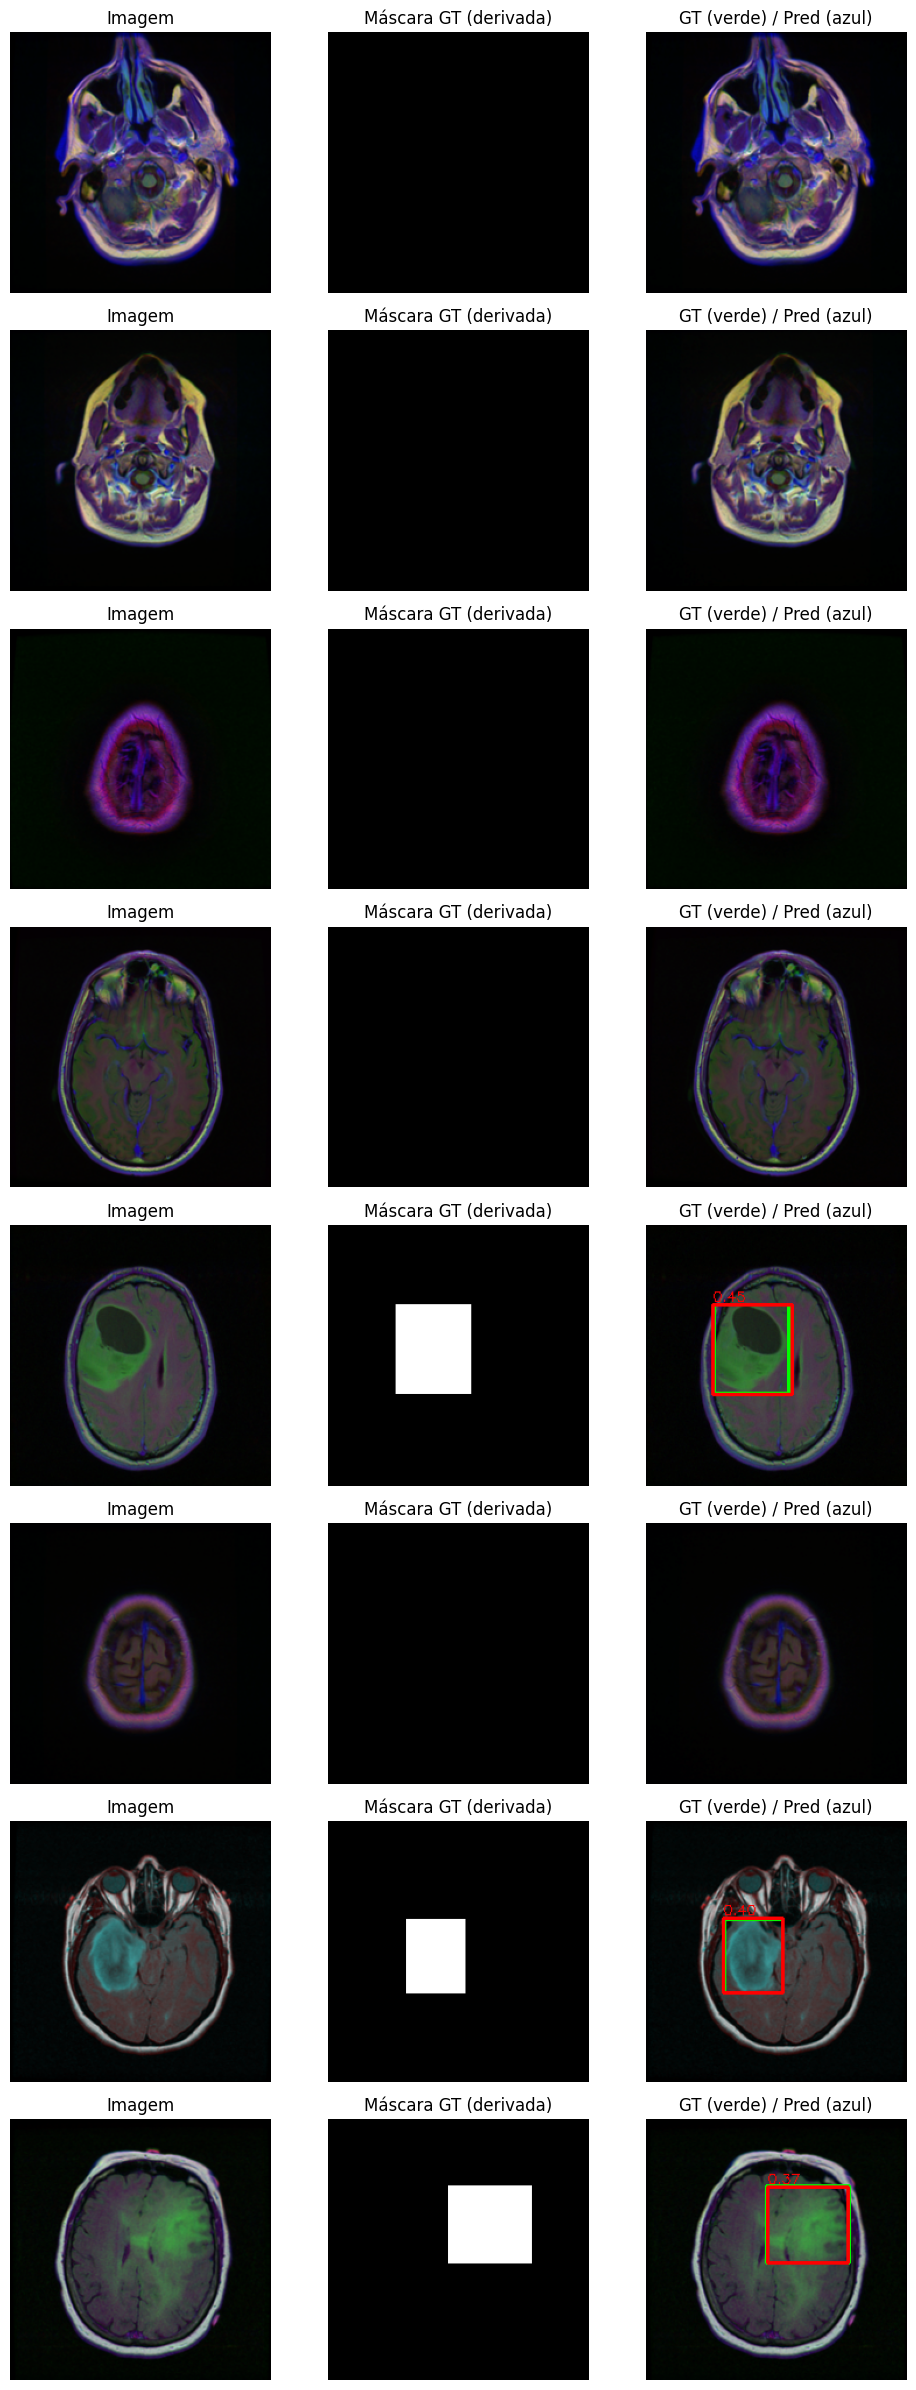

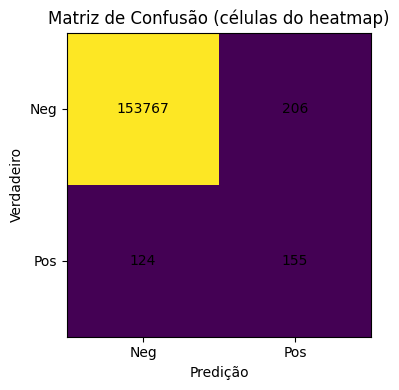

[Confusão/heatmap] TN=153767 FP=206 FN=124 TP=155
[mAP] AP@0.50=0.7883 | mAP@0.50 (1 classe)=0.7883


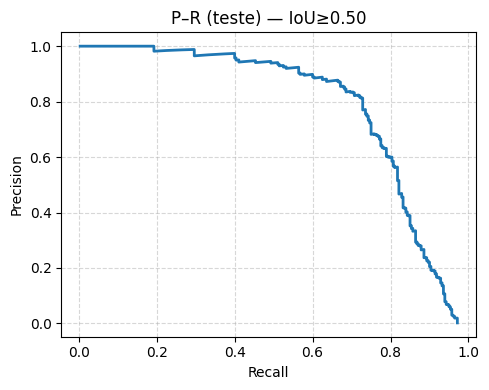

In [ ]:

# DINOv3 ViT-S/16 (PyTorch Hub) + Detecção (LGG MRI - Kaggle)
# Descongelando apenas os ÚLTIMOS BLOCOS do DINOv3

!pip -q install kagglehub==0.3.4 timm==1.0.9 torchmetrics==1.4.0.post0 opencv-python==4.10.0.84


import os, sys, math, glob, random, time
from pathlib import Path
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms as T
from torchmetrics.classification import BinaryPrecision, BinaryRecall
import matplotlib.pyplot as plt
import kagglehub
from contextlib import nullcontext


SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# Hiperparâmetros de finetuning do backbone

TRAIN_BACKBONE = True          # True => vai descongelar os últimos blocos selecionados
UNFREEZE_N_BLOCKS = 2          # quantos blocos finais do ViT descongelar (1 ou 2)
UNFREEZE_LAYERNORM = True      # também descongelar todas as LayerNorms
HEAD_LR = 1e-3                 # LR do head de detecção
BACKBONE_LR = 1e-5             # LR menor para o backbone
BACKBONE_WD = 1e-5             # WD do backbone (leve)


# Baixa o dataset do Kaggle (LGG MRI)

path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")
print("Path to dataset files:", path)
DATA_ROOT = Path(path)


# Clonar dinov3 e baixar o checkpoint .pth solicitado

%cd /content
if not Path("dinov3").exists():
    !git clone -q https://github.com/facebookresearch/dinov3.git

# Mesmo checkpoint ViT-S/16 (LVD-1689M)
ckpt_url = "https://dinov3.llamameta.net/dinov3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoidHE2NDVwN3RubW5vaDFsdTNybzFoeGk3IiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3NTgzOTkxNDh9fX1dfQ__&Signature=uPP9HrvqSFoRT-K2M5DinQ2U3MJPK1vEw5cxKq17C3xtofYe1WkAS2XimxnBhYAFsR62SopNtNDl4VtJqOxIVBM1b2lalQHjOhO1mA9fGY8fK0mxvXIyiw-Jc5UmkLGPzAVB25uj4B2tTWkUnouo8QNyHGTC1E6hnDc8Pm%7EMFp8WZra5qiDYr6L9AoZtcGpGvN2EetCcIbmnGxJh80W0PL-vrJGEaz0pzlSEht9CFQxGTSZ%7ERad9TSyU5wVW7shTDw3LBuglmGP-er0fBa44TEAO6f9N8KgRhQn99bYVZGYyit3z78nwcrgRKNg4avnzpAXACZenfENbwdo3ma9aKg__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=772328725411080"
ckpt_path = "/content/dinov3_vits16_pretrain_lvd1689m-08c60483.pth"
if not Path(ckpt_path).exists():
    !wget -q --content-disposition -O "{ckpt_path}" "{ckpt_url}"
print("Checkpoint .pth em:", ckpt_path)


# Listar pares (imagem, máscara)

def find_image_mask_pairs(root: Path):
    img_exts = {".png",".jpg",".jpeg",".tif",".tiff"}
    all_imgs = [p for p in root.rglob("*") if p.suffix.lower() in img_exts and ("mask" not in p.stem.lower())]
    pairs = []
    for img in all_imgs:
        stem = img.stem
        cand = list(img.parent.glob(stem + "_mask.*"))
        if not cand:
            cand = [p for p in img.parent.glob("*") if ("mask" in p.stem.lower()) and p.suffix.lower() in img_exts]
        if cand:
            pairs.append((img, cand[0]))
    return pairs

pairs = find_image_mask_pairs(DATA_ROOT)
print(f"Total de pares encontrados: {len(pairs)}")
random.shuffle(pairs)


# Dataset e Transforms (torchvision puro) — DETECÇÃO

IMG_SIZE = 224  # múltiplo de 16 => grid 14x14
IMG_PATCH = 16
GRID = IMG_SIZE // IMG_PATCH   # 14
STRIDE = IMG_PATCH

mean = (0.485, 0.456, 0.406); std = (0.229, 0.224, 0.225)

train_tf = T.Compose([
    T.ToTensor(),
    T.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    T.ConvertImageDtype(torch.float32),
    T.Normalize(mean, std),
])
val_tf = T.Compose([
    T.ToTensor(),
    T.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    T.ConvertImageDtype(torch.float32),
    T.Normalize(mean, std),
])

def apply_simple_aug(img, mask):
    if random.random() < 0.5:
        img  = np.ascontiguousarray(np.fliplr(img))
        mask = np.ascontiguousarray(np.fliplr(mask))
    if random.random() < 0.2:
        alpha = 1.0 + random.uniform(-0.2, 0.2)
        beta  = random.uniform(-20, 20)
        img = np.clip(alpha*img + beta, 0, 255).astype(np.uint8)
    return img, mask

def mask_to_boxes(mask_np, min_area=10):
    cnts, _ = cv2.findContours((mask_np>0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in cnts:
        x,y,w,h = cv2.boundingRect(c)
        if w*h >= min_area:
            x1,y1,x2,y2 = x, y, x+w, y+h
            boxes.append([x1,y1,x2,y2])
    return boxes

class MRIDetDataset(Dataset):
    def __init__(self, pairs, img_transform, is_train=False):
        self.pairs = pairs
        self.img_transform = img_transform
        self.is_train = is_train
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        img_path, msk_path = self.pairs[idx]
        img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if img is None: raise RuntimeError(f"Falha ao ler imagem: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(msk_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            img_maybe = cv2.imread(str(msk_path), cv2.IMREAD_COLOR)
            if img_maybe is None: raise RuntimeError(f"Falha ao ler máscara: {msk_path}")
            mask = cv2.cvtColor(img_maybe, cv2.COLOR_BGR2GRAY)

        _, mask = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY)

        if self.is_train:
            img, mask = apply_simple_aug(img, mask)

        img_res  = cv2.resize(img,  (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        mask_res = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        boxes = mask_to_boxes(mask_res, min_area=10)
        img_t = (train_tf if self.is_train else val_tf)(img_res)

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.ones((len(boxes),), dtype=torch.long)
        }
        return img_t, target

# Split 80/10/10
n_total = len(pairs)
n_train = int(0.8 * n_total); n_val = int(0.1 * n_total); n_test = n_total - n_train - n_val
ds_train = MRIDetDataset(pairs[:n_train], img_transform=train_tf, is_train=True)
ds_val   = MRIDetDataset(pairs[n_train:n_train+n_val], img_transform=val_tf, is_train=False)
ds_test  = MRIDetDataset(pairs[n_train+n_val:], img_transform=val_tf, is_train=False)

def collate_det(batch):
    imgs, targets = zip(*batch)
    return torch.stack(imgs,0), list(targets)

batch_size = 8
train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True,  num_workers=2,
                          pin_memory=True, drop_last=True, collate_fn=collate_det)
val_loader   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=2,
                          pin_memory=True, collate_fn=collate_det)
test_loader  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False, num_workers=2,
                          pin_memory=True, collate_fn=collate_det)
print(f"[DET] train={len(ds_train)} val={len(ds_val)} test={len(ds_test)}")


# Carregar ViT-S/16 (Hub) + descongelar últimos blocos

REPO_DIR = "/content/dinov3"
dinov3_vits16 = torch.hub.load(
    REPO_DIR, 'dinov3_vits16', source='local', weights=ckpt_path
).to(device)

# Congela tudo inicialmente
for p in dinov3_vits16.parameters():
    p.requires_grad = False

# Tenta localizar os blocos Transformer
blocks = getattr(dinov3_vits16, "blocks", None)
if blocks is None and hasattr(dinov3_vits16, "encoder"):
    blocks = getattr(dinov3_vits16.encoder, "blocks", None)

# Descongela somente os últimos N blocos
if TRAIN_BACKBONE and blocks is not None and len(blocks) > 0:
    for b in list(blocks)[-UNFREEZE_N_BLOCKS:]:
        for p in b.parameters():
            p.requires_grad = True

# (Opcional) Descongelar todas as LayerNorms (adaptação suave)
if TRAIN_BACKBONE and UNFREEZE_LAYERNORM:
    for m in dinov3_vits16.modules():
        if isinstance(m, nn.LayerNorm):
            for p in m.parameters():
                p.requires_grad = True

# Define modo train/eval do backbone conforme haja algo treinável
if TRAIN_BACKBONE and any(p.requires_grad for p in dinov3_vits16.parameters()):
    dinov3_vits16.train()
else:
    dinov3_vits16.eval()


# Extração robusta de PATCH TOKENS (com suporte a gradiente)

def _pick_best_tensor(candidates, img_size=224, patch=16):
    grid = (img_size // patch) * (img_size // patch)
    for t in candidates:
        if torch.is_tensor(t) and t.ndim == 3:
            B, N, C = t.shape
            if N in (grid, grid+1) and C >= 128:
                return t
    for t in candidates:
        if torch.is_tensor(t) and t.ndim == 4:
            B, C, H, W = t.shape
            if H * W == grid and C >= 128:
                return t
    return None

def _collect_forward_tensors(m, x, requires_grad=False):
    candidates, handles = [], []
    def hook(_, __, out):
        if torch.is_tensor(out): candidates.append(out)
        elif isinstance(out, (list, tuple)):
            candidates.extend([t for t in out if torch.is_tensor(t)])
        elif isinstance(out, dict):
            candidates.extend([v for v in out.values() if torch.is_tensor(v)])
    for sub in m.modules():
        try:
            h = sub.register_forward_hook(hook); handles.append(h)
        except: pass
    ctx = nullcontext() if requires_grad else torch.inference_mode()
    with ctx:
        _ = m(x)
    for h in handles:
        try: h.remove()
        except: pass
    return candidates

def extract_patch_tokens(backbone, x, img_size=224, patch=16, requires_grad=False):
    grid = (img_size // patch) * (img_size // patch)
    ctx = nullcontext() if requires_grad else torch.inference_mode()
    with ctx:
        if hasattr(backbone, "get_intermediate_layers"):
            try:
                outs = backbone.get_intermediate_layers(x, n=1, return_class_token=True)
            except TypeError:
                try: outs = backbone.get_intermediate_layers(x, 1, True)
                except TypeError: outs = backbone.get_intermediate_layers(x, 1)
            if isinstance(outs, (list, tuple)):
                z = next((t for t in outs if torch.is_tensor(t) and t.ndim in (3,4)), None)
                if z is not None:
                    if z.ndim == 4: return z
                    B, N, C = z.shape
                    if N == grid + 1: z = z[:, 1:, :]
                    h = w = img_size // patch
                    return z.transpose(1, 2).reshape(B, C, h, w).contiguous()
        if hasattr(backbone, "forward_features"):
            feat = backbone.forward_features(x)
            pool = []
            if torch.is_tensor(feat): pool = [feat]
            elif isinstance(feat, (list, tuple)): pool = [t for t in feat if torch.is_tensor(t)]
            elif isinstance(feat, dict): pool = [v for v in feat.values() if torch.is_tensor(v)]
            z = _pick_best_tensor(pool, img_size, patch)
            if z is not None:
                if z.ndim == 4: return z
                B, N, C = z.shape
                if N == grid + 1: z = z[:, 1:, :]
                h = w = img_size // patch
                return z.transpose(1, 2).reshape(B, C, h, w).contiguous()
        cands = _collect_forward_tensors(backbone, x, requires_grad=requires_grad)
        z = _pick_best_tensor(cands, img_size, patch)
        if z is None:
            only_bc = any(torch.is_tensor(t) and t.ndim == 2 for t in cands)
            if only_bc: raise RuntimeError("Backbone gerou apenas embeddings globais [B,C].")
            raise RuntimeError("Não foi possível localizar tokens/feature map intermediário.")
        if z.ndim == 4: return z
        B, N, C = z.shape
        if N == grid + 1: z = z[:, 1:, :]
        h = w = img_size // patch
        return z.transpose(1, 2).reshape(B, C, h, w).contiguous()

class DinoV3FeatureExtractor(nn.Module):
    def __init__(self, backbone, img_size=IMG_SIZE, patch=IMG_PATCH, trainable=False):
        super().__init__()
        self.backbone = backbone
        self.img_size = img_size
        self.patch = patch
        self.trainable = trainable
    def forward(self, x):
        return extract_patch_tokens(
            self.backbone, x, self.img_size, self.patch,
            requires_grad=self.trainable
        )

# Descobrir embed_dim de forma automática
with torch.no_grad():
    xb, _ = next(iter(train_loader))
    xb = xb.to(device)
    fmap = extract_patch_tokens(dinov3_vits16, xb, img_size=IMG_SIZE, patch=IMG_PATCH, requires_grad=False)
embed_dim = fmap.shape[1]
print("Feature map:", tuple(fmap.shape), "embed_dim:", embed_dim)

feat_extractor = DinoV3FeatureExtractor(
    dinov3_vits16, img_size=IMG_SIZE, patch=IMG_PATCH, trainable=TRAIN_BACKBONE
).to(device)


# Head de detecção anchor-free (heatmap + box LTRB)

def cell_center(i, j, stride=STRIDE):
    y = i*stride + stride/2.0
    x = j*stride + stride/2.0
    return x, y

class DetHead(nn.Module):
    def __init__(self, in_ch, out_classes=1, hidden=256):
        super().__init__()
        self.up1 = nn.Sequential(
            nn.Conv2d(in_ch, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden),
            nn.ReLU(inplace=True)
        )
        self.heatmap = nn.Conv2d(hidden, out_classes, 1)  # logits
        self.box     = nn.Conv2d(hidden, 4, 1)           # l,t,r,b
        nn.init.constant_(self.heatmap.bias, -2.0)
    def forward(self, f):
        h = self.up1(f)
        return self.heatmap(h), self.box(h)

class DetModel(nn.Module):
    def __init__(self, feat_extractor, in_ch):
        super().__init__()
        self.backbone = feat_extractor
        self.decoder  = DetHead(in_ch, out_classes=1, hidden=256)
    def forward(self, x):
        f = self.backbone(x)            # agora com/sem grad conforme trainable
        hm, box = self.decoder(f)
        return hm, box

model = DetModel(feat_extractor, in_ch=embed_dim).to(device)


# Perdas, otimizador e métricas

def focal_loss(inputs, targets, alpha=0.25, gamma=2.0, eps=1e-6):
    p  = torch.sigmoid(inputs)
    pt = p*targets + (1-p)*(1-targets)
    w  = alpha*targets + (1-alpha)*(1-targets)
    return (-w * (1-pt).pow(gamma) * torch.log(pt.clamp_min(eps))).mean()

metric_prec = BinaryPrecision().to(device)
metric_rec  = BinaryRecall().to(device)

# Otimizador com dois grupos: head (LR maior) e backbone (LR menor)
backbone_trainable_params = [p for p in feat_extractor.backbone.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW([
    {"params": model.decoder.parameters(),    "lr": HEAD_LR,     "weight_decay": 1e-4},
    {"params": backbone_trainable_params,     "lr": BACKBONE_LR, "weight_decay": BACKBONE_WD},
])
scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))

def build_targets(batch_targets):
    B = len(batch_targets)
    hm_t    = torch.zeros((B,1,GRID,GRID), dtype=torch.float32, device=device)
    posmask = torch.zeros_like(hm_t)
    box_t   = torch.zeros((B,4,GRID,GRID), dtype=torch.float32, device=device)
    for b, tgt in enumerate(batch_targets):
        if len(tgt["boxes"]) == 0: continue
        for (x1,y1,x2,y2) in tgt["boxes"].tolist():
            cx, cy = (x1+x2)/2.0, (y1+y2)/2.0
            j = int(cx // STRIDE)
            i = int(cy // STRIDE)
            if i<0 or j<0 or i>=GRID or j>=GRID:
                continue
            ccx, ccy = cell_center(i,j)
            l = max(0.0, ccx - x1)
            t = max(0.0, ccy - y1)
            r = max(0.0, x2 - ccx)
            b_ = max(0.0, y2 - ccy)
            hm_t[b,0,i,j] = 1.0
            posmask[b,0,i,j] = 1.0
            box_t[b,:,i,j] = torch.tensor([l,t,r,b_], device=device)
    return hm_t, posmask, box_t


# Loop de treino/val

def run_epoch(loader, model, optimizer=None, thr=0.3, lam_l1=1.0):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    running_loss = running_prec = running_rec = 0.0
    n_batches = 0

    for xb, tgt_list in loader:
        xb = xb.to(device, non_blocking=True)
        hm_t, posmask, box_t = build_targets(tgt_list)

        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            hm, box = model(xb)
            lf = focal_loss(hm, hm_t)
            l1 = torch.abs(box - box_t) * posmask
            l1 = l1.sum() / (posmask.sum().clamp(min=1.0))
            loss = lf + lam_l1*l1

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            # (Opcional) estabilidade extra
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

        with torch.no_grad():
            pred_bin = (torch.sigmoid(hm) > thr).to(torch.int)
            targ_bin = (hm_t > 0.5).to(torch.int)
            pb = pred_bin.view(-1).to(device)
            tb = targ_bin.view(-1).to(device)
            prec = metric_prec(pb, tb).item()
            rec  = metric_rec(pb, tb).item()

        running_loss += loss.item(); running_prec += prec; running_rec += rec; n_batches += 1

    return running_loss/n_batches, running_prec/n_batches, running_rec/n_batches

EPOCHS = 150
best_val = 0.0
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_prec, tr_rec = run_epoch(train_loader, model, optimizer, thr=0.3)
    with torch.no_grad():
        va_loss, va_prec, va_rec = run_epoch(val_loader, model, optimizer=None, thr=0.3)
    print(f"[{epoch:02d}/{EPOCHS}] "
          f"train_loss={tr_loss:.4f} Precision={tr_prec:.4f} Recall={tr_rec:.4f} | "
          f"val_loss={va_loss:.4f} Precision={va_prec:.4f} Recall={va_rec:.4f} | {time.time()-t0:.1f}s")
    if va_rec > best_val:
        best_val = va_rec
        torch.save(model.state_dict(), "/content/dinov3_vits16_lgg_det_best.pt")

print("Detecção treinada. Melhor Recall (val):", best_val)


# Avaliação no teste + Visualização

with torch.no_grad():
    te_loss, te_prec, te_rec = run_epoch(test_loader, model, optimizer=None, thr=0.3)
print(f"[TEST] loss={te_loss:.4f} Precision={te_prec:.4f} Recall={te_rec:.4f}")

def decode_topk(hm, box, k=50, thr=0.3):
    p = torch.sigmoid(hm)[0,0]  # [14,14]
    b = box[0]                  # [4,14,14]
    scores = []
    for i in range(GRID):
        for j in range(GRID):
            s = p[i,j].item()
            if s < thr: continue
            ccx, ccy = cell_center(i,j)
            l,t,r,bb = b[:,i,j].tolist()
            x1,y1 = ccx - l, ccy - t
            x2,y2 = ccx + r, ccy + bb
            x1,y1 = max(0,x1), max(0,y1)
            x2,y2 = min(IMG_SIZE,x2), min(IMG_SIZE,y2)
            if x2>x1 and y2>y1:
                scores.append((s, x1,y1,x2,y2))
    scores.sort(key=lambda x: x[0], reverse=True)
    return scores[:k]

def nms(boxes, iou_thr=0.5):
    out = []
    boxes = boxes[:]
    while boxes:
        best = boxes.pop(0)
        out.append(best)
        keep = []
        ax1,ay1,ax2,ay2 = best[1:]
        a = (ax2-ax1)*(ay2-ay1)
        for cand in boxes:
            bx1,by1,bx2,by2 = cand[1:]
            inter = max(0, min(ax2,bx2)-max(ax1,bx1)) * max(0, min(ay2,by2)-max(ay1,by1))
            b = (bx2-bx1)*(by2-by1)
            iou = inter / (a+b-inter+1e-6)
            if iou <= iou_thr: keep.append(cand)
        boxes = keep
    return out

def show_examples(loader, model, k=5, score_thr=0.3, iou_thr=0.5):
    model.eval()
    xb_all, tgt_all = next(iter(loader))
    xb_all = xb_all.to(device)
    with torch.no_grad():
        hm, box = model(xb_all)
    std = np.array((0.229, 0.224, 0.225)); mean = np.array((0.485, 0.456, 0.406))
    xb_np = xb_all.cpu().numpy().transpose(0,2,3,1)
    xb_vis = xb_np * std[None,None,None,:] + mean[None,None,None,:]
    xb_vis = np.clip(xb_vis, 0.0, 1.0)

    rows = min(k, xb_vis.shape[0])
    plt.figure(figsize=(10, 3*rows))
    for i in range(rows):
        preds = decode_topk(hm[i:i+1], box[i:i+1], k=50, thr=score_thr)
        preds = nms(preds, iou_thr=iou_thr)
        vis = (xb_vis[i]*255).astype(np.uint8).copy()
        # GT (verde)
        for (x1,y1,x2,y2) in tgt_all[i]["boxes"].numpy():
            cv2.rectangle(vis, (int(x1),int(y1)), (int(x2),int(y2)), (0,255,0), 2)
        # Preds (azul)
        for s,x1,y1,x2,y2 in preds:
            cv2.rectangle(vis, (int(x1),int(y1)), (int(x2),int(y2)), (255,0,0), 2)
            cv2.putText(vis, f"{s:.2f}", (int(x1),max(0,int(y1)-3)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,0,0), 1)
        plt.subplot(rows,3,3*i+1); plt.imshow(xb_vis[i]); plt.axis('off'); plt.title("Imagem")
        # Máscara GT (derivada das caixas para referência)
        m = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        for (x1,y1,x2,y2) in tgt_all[i]["boxes"].numpy():
            cv2.rectangle(m, (int(x1),int(y1)), (int(x2),int(y2)), 255, -1)
        plt.subplot(rows,3,3*i+2); plt.imshow(m, cmap='gray'); plt.axis('off'); plt.title("Máscara GT (derivada)")
        plt.subplot(rows,3,3*i+3); plt.imshow(vis); plt.axis('off'); plt.title("GT (verde) / Pred (azul)")
    plt.tight_layout(); plt.show()

# Visualização
show_examples(test_loader, model, k=20, score_thr=0.2, iou_thr=0.3)


# +++ MÉTRICAS ADICIONAIS +++


def compute_cell_confusion(loader, model, thr=0.3):
    """
    Matriz de confusão baseada nas células do heatmap (mesmo critério usado em Precision/Recall).
    Retorna tn, fp, fn, tp e mostra a figura.
    """
    model.eval()
    tn = fp = fn = tp = 0
    with torch.no_grad():
        for xb, tgt_list in loader:
            xb = xb.to(device, non_blocking=True)
            hm_t, posmask, _ = build_targets(tgt_list)  # hm_t = {0,1} nas células com objeto
            hm, _ = model(xb)
            pred_bin = (torch.sigmoid(hm) > thr).to(torch.int)
            targ_bin = (hm_t > 0.5).to(torch.int)

            p = pred_bin.view(-1)
            t = targ_bin.view(-1)

            tp += ((p == 1) & (t == 1)).sum().item()
            tn += ((p == 0) & (t == 0)).sum().item()
            fp += ((p == 1) & (t == 0)).sum().item()
            fn += ((p == 0) & (t == 1)).sum().item()

    # Visualização
    import matplotlib.pyplot as plt
    import numpy as np

    cm = np.array([[tn, fp],
                   [fn, tp]], dtype=np.int64)

    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, interpolation='nearest')
    ax.set_title("Matriz de Confusão (células do heatmap)")
    ax.set_xlabel("Predição"); ax.set_ylabel("Verdadeiro")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Neg", "Pos"]); ax.set_yticklabels(["Neg", "Pos"])
    # anotações
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center")
    plt.tight_layout(); plt.show()

    return tn, fp, fn, tp


# --------- mAP@0.50 (IoU) de detecção por caixas ---------

def iou_xyxy(a, b):
    """
    IoU entre duas caixas [x1,y1,x2,y2] (float).
    """
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_w = max(0.0, min(ax2, bx2) - max(ax1, bx1))
    inter_h = max(0.0, min(ay2, by2) - max(ay1, by1))
    inter = inter_w * inter_h
    area_a = max(0.0, (ax2 - ax1)) * max(0.0, (ay2 - ay1))
    area_b = max(0.0, (bx2 - bx1)) * max(0.0, (by2 - by1))
    union = area_a + area_b - inter + 1e-12
    return inter / union


def evaluate_map(loader, model, score_thr_eval=0.0, iou_thr=0.50, nms_iou=0.5, topk=200):
    """
    Calcula AP e mAP@0.50 (única classe) no dataset do 'loader'.
    Estratégia:
      - Para cada imagem, decodifica predições (decode_topk), aplica NMS.
      - Coleta (score, is_TP) após matching guloso com GT (IoU>=iou_thr).
      - Agrega todas as predições do dataset, ordena por score desc,
        computa curva P–R e AP (integração por trapézios).
    """
    model.eval()
    all_scores = []
    all_tp = []
    n_gt_total = 0

    with torch.no_grad():
        for xb, tgt_list in loader:
            xb = xb.to(device, non_blocking=True)
            hm, box = model(xb)

            B = xb.size(0)
            for i in range(B):
                # GT
                gt_boxes = tgt_list[i]["boxes"].cpu().numpy().tolist()
                n_gt_total += len(gt_boxes)
                # Preds
                preds = decode_topk(hm[i:i+1], box[i:i+1], k=topk, thr=score_thr_eval)
                preds = nms(preds, iou_thr=nms_iou)

                matched_gt = set()
                # ordena por score já está vindo decrescente; garantimos
                preds_sorted = sorted(preds, key=lambda x: x[0], reverse=True)

                for s, x1, y1, x2, y2 in preds_sorted:
                    pred_box = (x1, y1, x2, y2)
                    # encontra melhor GT disponível
                    best_iou, best_j = 0.0, -1
                    for j, g in enumerate(gt_boxes):
                        if j in matched_gt:
                            continue
                        iou = iou_xyxy(pred_box, g)
                        if iou > best_iou:
                            best_iou, best_j = iou, j

                    if best_iou >= iou_thr and best_j >= 0:
                        all_scores.append(float(s))
                        all_tp.append(1)  # true positive
                        matched_gt.add(best_j)
                    else:
                        all_scores.append(float(s))
                        all_tp.append(0)  # false positive

    if n_gt_total == 0:
        print("Aviso: não há GT no conjunto para calcular AP/mAP.")
        return 0.0, 0.0, ([], [], [])

    # Ordena globalmente por score desc
    idx = np.argsort(-np.array(all_scores))
    tp_sorted = np.array(all_tp)[idx]

    # cumulativos
    tp_cum = np.cumsum(tp_sorted)
    fp_cum = np.cumsum(1 - tp_sorted)

    recalls = tp_cum / max(1, n_gt_total)
    precisions = tp_cum / np.maximum(tp_cum + fp_cum, 1e-12)

    # AP por integração numérica (trapézios)
    # Garantir monotonicidade da precisão (método VOC 2010+)
    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([1.0], precisions, [0.0]))
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])
    ap = np.sum((mrec[1:] - mrec[:-1]) * mpre[1:])

    # Como é single-class, mAP == AP
    return float(ap), float(ap), (recalls, precisions, tp_cum)


# 1) Matriz de confusão (por células do heatmap)
tn, fp, fn, tp = compute_cell_confusion(test_loader, model, thr=0.3)
print(f"[Confusão/heatmap] TN={tn} FP={fp} FN={fn} TP={tp}")

# 2) mAP@0.50 (IoU) por caixas
ap50, map50, (rec, prec, tpc) = evaluate_map(
    test_loader, model, score_thr_eval=0.0, iou_thr=0.50, nms_iou=0.5, topk=200
)
print(f"[mAP] AP@0.50={ap50:.4f} | mAP@0.50 (1 classe)={map50:.4f}")

# Curva P–R (opcional, ajuda a visualizar)
plt.figure(figsize=(5,4))
plt.plot(rec, prec, lw=2)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("P–R (teste) — IoU≥0.50")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()




# DINOv3 ViT-7B/16 (LOCAL, PyTorch Hub) - Segmentação ADE20K (M2F)


Device: cuda
Head em: /content/dinov3_vit7b16_ade20k_m2f_head.pth
Backbone em: /content/dinov3_vit7b16_pretrain_lvd1689m.pth (garanta que foi baixado com sucesso)
embed dim 4096
interaction_indexes [9, 19, 29, 39]
patch_size 16


/usr/local/lib/python3.12/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


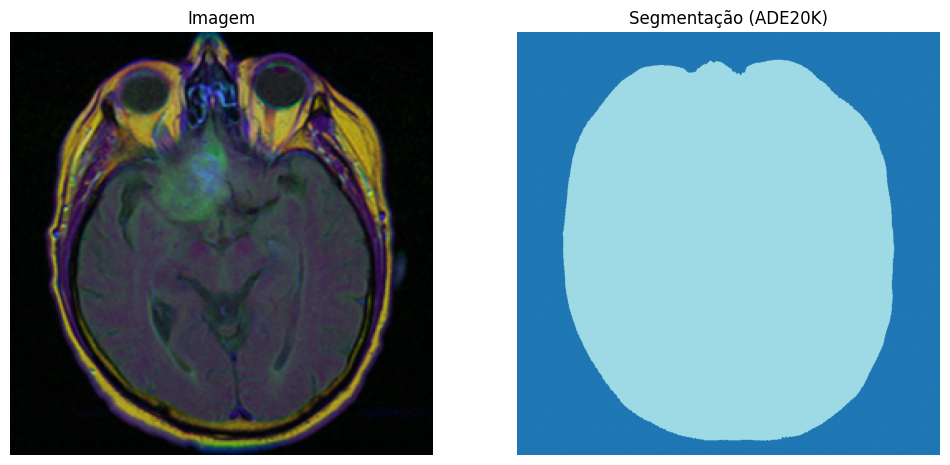

In [ ]:
# ===========================================
#
# Requisitos: link do HEAD (ADE20K M2F) e do BACKBONE ViT-7B/16 (LVD-1689M)
# ===========================================

# 1) Instalações básicas
!pip -q install opencv-python==4.10.0.84 matplotlib==3.8.4

import os, sys, subprocess, shlex, io, requests
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.transforms import v2

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# 2) Clonar repositório oficial (uso LOCAL do torch.hub)
REPO_DIR = "/content/dinov3"
if not os.path.exists(os.path.join(REPO_DIR, "README.md")):
    !git clone -q https://github.com/facebookresearch/dinov3 $REPO_DIR
sys.path.append(REPO_DIR)

# 3) URLs dos pesos
#    - HEAD (ADE20K M2F) — você já forneceu:
HEAD_URL = "https://dinov3.llamameta.net/dinov3_vit7b16/dinov3_vit7b16_ade20k_m2f_head-bf307cb1.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXshIjoidHE2NDVwN3RubW5vaDFsdTNybzFoeGk3IiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3NTgzOTkxNDh9fX1dfQ__&Signature=uPP9HrvqSFoRT-K2M5DinQ2U3MJPK1vEw5cxKq17C3xtofYe1WkAS2XimxnBhYAFsR62SopNtNDl4VtJqOxIVBM1b2lalQHjOhO1mA9fGY8fK0mxvXIyiw-Jc5UmkLGPzAVB25uj4B2tTWkUnouo8QNyHGTC1E6hnDc8Pm%7EMFp8WZra5qiDYr6L9AoZtcGpGvN2EetCcIbmnGxJh80W0PL-vrJGEaz0pzlSEht9CFQxGTSZ%7ERad9TSyU5wVW7shTDw3LBuglmGP-er0fBa44TEAO6f9N6KgRhQn99bYVZGYyit3z78nwcrhRKNg4avnzpAXACZenfENbwdo3ma9aKg__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=772328725411080"

#    - BACKBONE (pré-treinado LVD-1689M) — COLE AQUI o link do ViT-7B/16 pretrain:
BACKBONE_URL = "https://dinov3.llamameta.net/dinov3_vit7b16/dinov3_vit7b16_pretrain_lvd1689m-a955f4ea.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoidHE2NDVwN3RubW5vaDFsdTNybzFoeGk3IiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbetaLm5ldFwvKiIsIkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc1ODM5OTE0OH19fV19&Signature=uPP9HrvqSFoRT-K2M5DinQ2U3MJPK1vEw5cxKq17C3xtofYe1WkAS2XimxnBhYAFsR62SopNtNDl4VtJqOxIVBM1b2lalQHjOhO1mA9fGY8fK0mxvXIyiw-Jc5UmkLGPzAVB25uj4B2tTWkUnouo8QNyHGTC1E6hnDc8Pm%7EMFp8WZra5qiDYr6L9AoZtcGpGvN2EetCcIbmnGxJh80W0PL-vrJGEaz0pzlSEht9CFQxGTSZ%7ERad9TSyU5wVW7shTDw3LBuglmGP-er0fBa44TEAO6f9N6KgRhQn99bYVZGYyit3z78nwcrhRKNg4avnzpAXACZenfENbwdo3ma9aKg__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=772328725411080"

# 4) Baixar para caminhos locais
HEAD_PATH = "/content/dinov3_vit7b16_ade20k_m2f_head.pth"
BACKBONE_PATH = "/content/dinov3_vit7b16_pretrain_lvd1689m.pth"

def wget(url, out):
    cmd = f'wget -q --content-disposition -O "{out}" "{url}"'
    subprocess.run(shlex.split(cmd), check=True)

if not os.path.exists(HEAD_PATH):
    wget(HEAD_URL, HEAD_PATH)

if BACKBONE_URL.startswith("http") and not os.path.exists(BACKBONE_PATH):
    wget(BACKBONE_URL, BACKBONE_PATH)
print("Head em:", HEAD_PATH)
print("Backbone em:", BACKBONE_PATH, "(garanta que foi baixado com sucesso)")

# 5) Carregar o SEGMENTOR (ViT-7B/16 + M2F ADE20K) via torch.hub LOCAL
#    O README mostra exatamente esse padrão: segmentor = torch.hub.load(..., 'dinov3_vit7b16_ms', weights=<HEAD>, backbone_weights=<BACKBONE>)
segmentor = torch.hub.load(
    REPO_DIR,
    'dinov3_vit7b16_ms',
    source='local',
    weights=HEAD_PATH,          # pesos do head ADE20K (M2F)
    backbone_weights=BACKBONE_PATH  # pesos do backbone ViT-7B/16 pretrain
).to(device).eval()

# 6) Transform e inferência (seguindo orientações do README)
#    Para LVD-1689M, usar transform ImageNet padrão:contentReference[oaicite:2]{index=2}.
def make_transform(resize_size: int = 896):
    # múltiplo de 16 em alta resolução para boa densidade
    from torchvision.transforms import v2
    resize_size = int(resize_size // 16) * 16
    to_tensor = v2.ToImage()
    resize = v2.Resize((resize_size, resize_size), antialias=True)
    to_float = v2.ToDtype(torch.float32, scale=True)
    normalize = v2.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
    return v2.Compose([to_tensor, resize, to_float, normalize])

# utilitário simples p/ carregar imagem da web (ou troque por upload do Colab)
def load_image_url(url: str) -> Image.Image:
    r = requests.get(url, stream=True); r.raise_for_status()
    return Image.open(io.BytesIO(r.content)).convert("RGB")

# Imagem de exemplo (troque por sua própria URL)
# img = "/content/tumor.jpg" # This was a string path

# Load the image using load_image_url
image_path = "/content/tumor.jpg"
img = Image.open(image_path).convert("RGB")


# 7) Inferência — opção A: mapa de classes argmax diretamente
transform = make_transform(896)
with torch.inference_mode():
    batch_img = transform(img)[None].to(device)
    raw_logits = segmentor(batch_img)  # [B, num_classes, H', W']

# 8) (Opcional) Pós-processamento com utilitário oficial para 'slide inference' + softmax
#    O README ilustra 'make_inference' para converter logits em mapa final (dim=1 softmax, argmax):contentReference[oaicite:3]{index=3}.
from functools import partial
import torch.nn.functional as F
from dinov3.eval.segmentation.inference import make_inference

with torch.inference_mode():
    segmentation_map = make_inference(
        batch_img,
        segmentor,
        inference_mode="slide",             # varredura em janelas
        decoder_head_type="m2f",            # head M2F
        rescale_to=(batch_img.shape[-1], batch_img.shape[-2]),
        n_output_channels=150,              # ADE20K tem 150 classes
        crop_size=(896, 896),
        stride=(896, 896),
        output_activation=partial(F.softmax, dim=1),
    ).argmax(dim=1, keepdim=True)          # [B,1,H,W]

# 9) Visualização
plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.imshow(img); plt.axis("off"); plt.title("Imagem")
plt.subplot(1,2,2); plt.imshow(segmentation_map[0,0].cpu(), cmap="tab20"); plt.axis("off"); plt.title("Segmentação (ADE20K)")
plt.show()

## DINOv3 ViT-7B/16 - Segmentação


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 117.2 MB/s eta 0:00:00
Device: cuda
Dataset em: /kaggle/input/lgg-mri-segmentation
Total de pares: 7858
#itens: train=6286 val=785 test=787
Downloading: "file:///content/dinov3_vit7b16_pretrain_lvd1689m.pth" to /root/.cache/torch/hub/checkpoints/dinov3_vit7b16_pretrain_lvd1689m.pth


100%|██████████| 25.0G/25.0G [01:05<00:00, 413MB/s]


Feature map: (8, 4096, 16, 16) embed_dim: 4096


/tmp/ipython-input-4244190387.py:297: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))
/tmp/ipython-input-4244190387.py:304: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
/tmp/ipython-input-4244190387.py:313: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  tot_loss += float(loss); tot_iou += metric_iou(pred,targ).item(); tot_f1 += metric_f1(pred,targ).item(); n+=1


[01/50] train: loss=0.4386 IoU=nan Dice=0.6132 | val: loss=0.4065 IoU=nan Dice=0.6904 | 408.6s
[02/50] train: loss=0.3926 IoU=nan Dice=0.6939 | val: loss=0.3981 IoU=nan Dice=0.7170 | 397.0s
[03/50] train: loss=0.3866 IoU=nan Dice=0.7150 | val: loss=0.3949 IoU=nan Dice=0.7308 | 397.2s
[04/50] train: loss=0.3829 IoU=nan Dice=0.7255 | val: loss=0.4007 IoU=nan Dice=0.6905 | 397.1s
[05/50] train: loss=0.3809 IoU=nan Dice=0.7379 | val: loss=0.3913 IoU=nan Dice=0.7450 | 397.7s
[06/50] train: loss=0.3778 IoU=nan Dice=0.7514 | val: loss=0.3931 IoU=nan Dice=0.7518 | 397.0s
[07/50] train: loss=0.3765 IoU=nan Dice=0.7615 | val: loss=0.3910 IoU=nan Dice=0.7493 | 397.0s
[08/50] train: loss=0.3746 IoU=nan Dice=0.7679 | val: loss=0.3890 IoU=nan Dice=0.7609 | 397.6s
[09/50] train: loss=0.3731 IoU=nan Dice=0.7779 | val: loss=0.3903 IoU=nan Dice=0.7571 | 397.1s
[10/50] train: loss=0.3720 IoU=nan Dice=0.7801 | val: loss=0.3920 IoU=nan Dice=0.7146 | 397.7s
[11/50] train: loss=0.3705 IoU=nan Dice=0.7803 | v

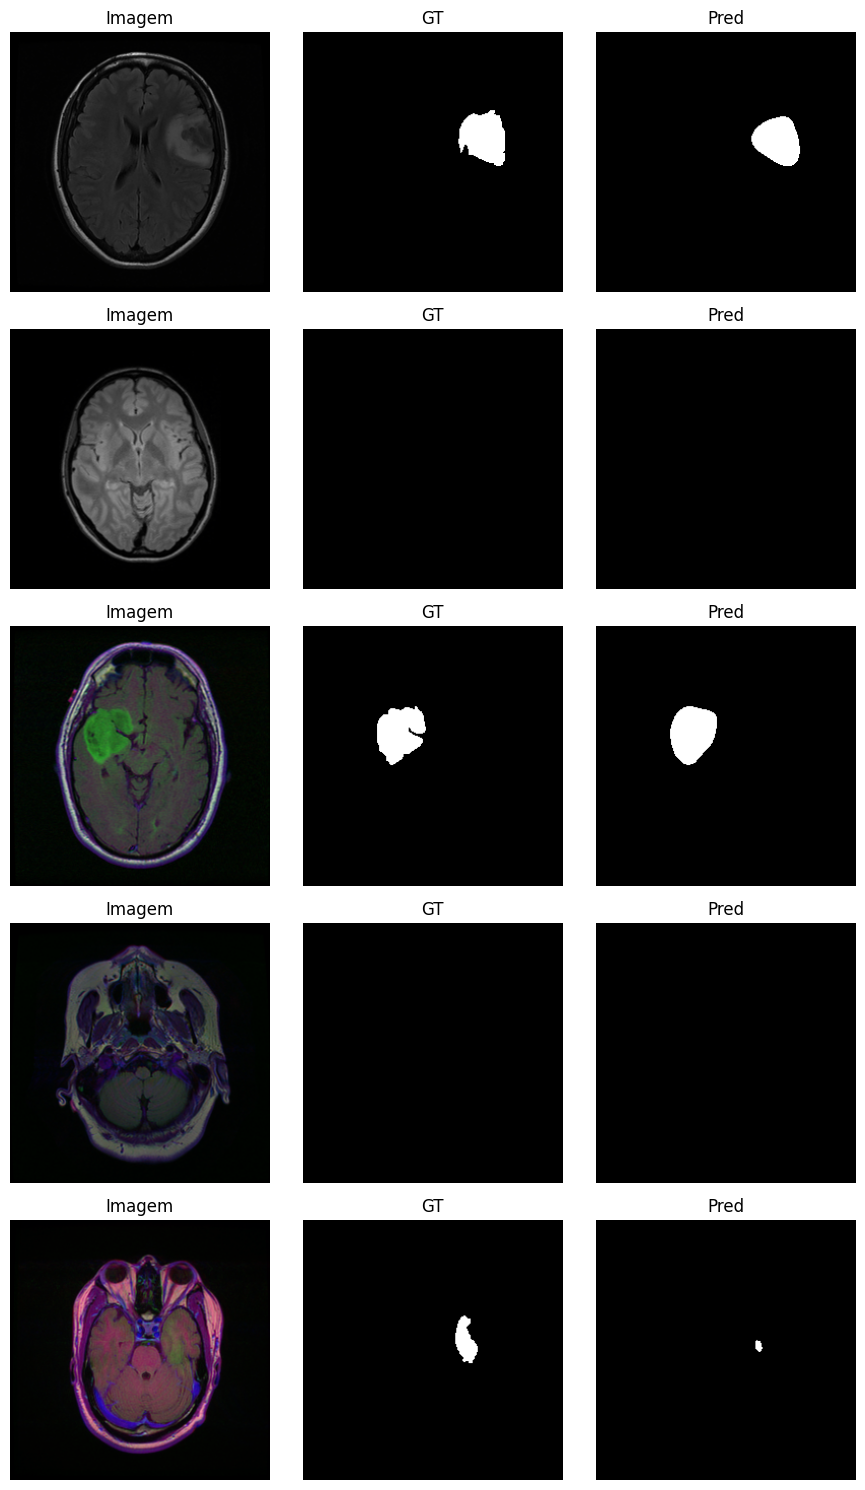

In [1]:
# ===========================================
# DINOv3 (LOCAL, PyTorch Hub) + Few-shot Seg (LGG MRI)
# Backbone congelado (ViT-L/16 SAT-493M por padrão) + decoder leve
# 100% local — sem HF
# ===========================================

# ---- Instalações mínimas
!pip -q install kagglehub==0.3.4 timm==1.0.9 torchmetrics==1.4.0.post0 opencv-python==4.10.0.84 matplotlib==3.8.4

# ---- Imports
import os, sys, io, math, glob, random, time, subprocess, shlex
from pathlib import Path
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.transforms import v2
from torchmetrics.classification import BinaryJaccardIndex, BinaryF1Score
import matplotlib.pyplot as plt
from PIL import Image
import kagglehub

# ---- Seeds / device
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ===========================================
# 1) Dataset LGG (Kaggle)
# ===========================================
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")
DATA_ROOT = Path(path)
print("Dataset em:", DATA_ROOT)

def find_pairs(root: Path):
    img_exts = {".png",".jpg",".jpeg",".tif",".tiff"}
    imgs = [p for p in root.rglob("*") if p.suffix.lower() in img_exts and ("mask" not in p.stem.lower())]
    pairs = []
    for img in imgs:
        cand = list(img.parent.glob(img.stem + "_mask.*"))
        if cand:
            pairs.append((img, cand[0]))
    return pairs

pairs = find_pairs(DATA_ROOT)
random.shuffle(pairs)
print("Total de pares:", len(pairs))

# split 80/10/10
n = len(pairs)
n_tr = int(0.8*n); n_va = int(0.1*n); n_te = n - n_tr - n_va
pairs_tr = pairs[:n_tr]; pairs_va = pairs[n_tr:n_tr+n_va]; pairs_te = pairs[n_tr+n_va:]

# ---- Transforms
IMG_SIZE = 256  # múltiplo de 16; 256 cabe bem na GPU com ViT-L
mean = (0.485, 0.456, 0.406); std = (0.229, 0.224, 0.225)

tf_train = v2.Compose([
    v2.ToImage(),
    v2.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean, std),
])
tf_eval = tf_train  # mesma normalização

def aug_np(img, msk):
    # flips simples
    if random.random() < 0.5:
        img  = np.ascontiguousarray(np.fliplr(img))
        msk  = np.ascontiguousarray(np.fliplr(msk))
    if random.random() < 0.2:
        # brilho/contraste leve
        a = 1.0 + random.uniform(-0.2, 0.2)
        b = random.uniform(-20, 20)
        img = np.clip(a*img + b, 0, 255).astype(np.uint8)
    return img, msk

class LGG(Dataset):
    def __init__(self, pairs, is_train=False):
        self.pairs = pairs
        self.is_train = is_train
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        ip, mp = self.pairs[idx]
        im = cv2.imread(str(ip), cv2.IMREAD_COLOR); im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
        m  = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
        _, m = cv2.threshold(m, 0, 255, cv2.THRESH_BINARY)
        if self.is_train:
            im, m = aug_np(im, m)
        im = cv2.resize(im, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        m  = cv2.resize(m,  (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        x = tf_train(im) if self.is_train else tf_eval(im)
        y = torch.from_numpy((m>0).astype(np.float32))[None, ...]
        return x, y

ds_tr = LGG(pairs_tr, True)
ds_va = LGG(pairs_va, False)
ds_te = LGG(pairs_te, False)

BATCH = 8
tr_loader = DataLoader(ds_tr, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
va_loader = DataLoader(ds_va, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
te_loader = DataLoader(ds_te, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print(f"#itens: train={len(ds_tr)} val={len(ds_va)} test={len(ds_te)}")

# ===========================================
# 2) DINOv3 backbone (LOCAL torch.hub) — congelado
#    Escolha do backbone:
#       (recomendado p/ VRAM) ViT-L/16 SAT-493M
#       (muito pesado)        ViT-7B/16 LVD-1689M
# ===========================================
REPO_DIR = "/content/dinov3"
if not Path(REPO_DIR, "README.md").exists():
    !git clone -q https://github.com/facebookresearch/dinov3 {REPO_DIR}
sys.path.append(REPO_DIR)

def wget(url, out):
    cmd = f'wget -q --content-disposition -O "{out}" "{url}"'
    subprocess.run(shlex.split(cmd), check=True)

# ---- URLs dos backbones (escolha UM)
#BACKBONE_URL = "https://dinov3.llamameta.net/dinov3_vitl16/dinov3_vitl16_pretrain_sat493m-eadcf0ff.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoidHE2NDVwN3RubW5vaDFsdTNybzFoeGk3IiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3NTgzOTkxNDh9fX1dfQ__&Signature=uPP9HrvqSFoRT-K2M5DinQ2U3MJPK1vEw5cxKq17C3xtofYe1WkAS2XimxnBhYAFsR62SopNtNDl4VtJqOxIVBM1b2lalQHjOhO1mA9fGY8fK0mxvXIyiw-Jc5UmkLGPzAVB25uj4B2tTWkUnouo8QNyHGTC1E6hnDc8Pm%7EMFp8WZra5qiDYr6L9AoZtcGpGvN2EetCcIbmnGxJh80W0PL-vrJGEaz0pzlSEht9CFQxGTSZ%7ERad9TSyU5wVW7shTDw3LBuglmGP-er0fBa44TEAO6f9N8KgRhQn99bYVZGYyit3z78nwcrgRKNg4avnzpAXACZenfENbwdo3ma9aKg__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=772328725411080"
#BACKBONE_PATH = "/content/dinov3_vitl16_pretrain_sat493m.pth"

# (Opcional, MUITO pesado) ViT-7B/16 — descomente se quiser tentar e tiver VRAM
BACKBONE_URL = "https://dinov3.llamameta.net/dinov3_vit7b16/dinov3_vit7b16_pretrain_lvd1689m-a955f4ea.pth?Policy=eyJTdGF0ZW1lbnQiOlt7InVuaXF1ZV9oYXNoIjoiMHhwMnVwMTNpN2VnM3F0MDQ2dXhhZXA0IiwiUmVzb3VyY2UiOiJodHRwczpcL1wvZGlub3YzLmxsYW1hbWV0YS5uZXRcLyoiLCJDb25kaXRpb24iOnsiRGF0ZUxlc3NUaGFuIjp7IkFXUzpFcG9jaFRpbWUiOjE3NTk2ODM2MDR9fX1dfQ__&Signature=tYhWijVxxPco6Js%7Ecdtb26KqcRpt1UZT2iqyOBA%7Ek7Ocd6ILXfNcpdG6xnCOzrEbpXp4n24LIDV5MZGItPngzptGQh5Lz6D694Q29ub-QtugsMkko1zMF5TNirEB4qsB2lhGAwWWw7tSuZn2HCVwViXCtGAWu1RAGbPJc-ShrXb1uW6egOxwNMrO59NtEtx-hmvqKXvO-FhOWUhqrfFsAbDgS4EQCDfMQmkOiaXUGQ8Dzj76hGr5kpoCnvj45MThRZZ9G5fkfA1NX0qQhR39QGWrxjNqyd8Pl9XmhIq9o5TmqHXPQ1pYk-xqejonbt5bFHmyl86YdgIRjdkvTBm0nA__&Key-Pair-Id=K15QRJLYKIFSLZ&Download-Request-ID=799371259485855"
BACKBONE_PATH = "/content/dinov3_vit7b16_pretrain_lvd1689m.pth"

if not Path(BACKBONE_PATH).exists():
    wget(BACKBONE_URL, BACKBONE_PATH)

# ---- Carregar backbone via hub (LOCAL)
backbone = torch.hub.load(
    REPO_DIR,
    'dinov3_vit7b16',          # mude para 'dinov3_vit7b16' se usar o 7B
    source='local',
    weights=BACKBONE_PATH
).to(device).eval()

# ===========================================
# 3) Extração de features (patch tokens) robusta
# ===========================================
PATCH = 16  # ViT/16
@torch.no_grad()
def _pick_best_tensor(cands, grid, min_c=128):
    for t in cands:
        if torch.is_tensor(t) and t.ndim == 3:
            B, N, C = t.shape
            if N in (grid, grid+1) and C >= min_c: return t
    for t in cands:
        if torch.is_tensor(t) and t.ndim == 4:
            B, C, H, W = t.shape
            if H*W == grid and C >= min_c: return t
    return None

def _collect_forward_tensors(m, x):
    cands, hs = [], []
    def hook(_, __, out):
        if torch.is_tensor(out): cands.append(out)
        elif isinstance(out, (list, tuple)):
            cands.extend([t for t in out if torch.is_tensor(t)])
        elif isinstance(out, dict):
            cands.extend([v for v in out.values() if torch.is_tensor(v)])
    for sub in m.modules():
        try:
            hs.append(sub.register_forward_hook(hook))
        except Exception:
            pass
    with torch.inference_mode():
        _ = m(x)
    for h in hs:
        try: h.remove()
        except Exception: pass
    return cands

@torch.no_grad()
def extract_fmap(backbone, x, img_size=IMG_SIZE, patch=PATCH):
    grid = (img_size//patch)*(img_size//patch)
    if hasattr(backbone, "get_intermediate_layers"):
        try:
            outs = backbone.get_intermediate_layers(x, n=1, return_class_token=True)
        except TypeError:
            try: outs = backbone.get_intermediate_layers(x, 1, True)
            except TypeError: outs = backbone.get_intermediate_layers(x, 1)
        if isinstance(outs, (list, tuple)):
            z = next((t for t in outs if torch.is_tensor(t) and t.ndim in (3,4)), None)
            if z is not None:
                if z.ndim == 4: return z
                B,N,C = z.shape
                if N == grid+1: z = z[:,1:,:]
                h=w=img_size//patch
                return z.transpose(1,2).reshape(B,C,h,w).contiguous()
    if hasattr(backbone, "forward_features"):
        feat = backbone.forward_features(x)
        pool=[]
        if torch.is_tensor(feat): pool=[feat]
        elif isinstance(feat,(list,tuple)): pool=[t for t in feat if torch.is_tensor(t)]
        elif isinstance(feat,dict): pool=[v for v in feat.values() if torch.is_tensor(v)]
        z = _pick_best_tensor(pool, grid)
        if z is not None:
            if z.ndim == 4: return z
            B,N,C = z.shape
            if N == grid+1: z = z[:,1:,:]
            h=w=img_size//patch
            return z.transpose(1,2).reshape(B,C,h,w).contiguous()
    cands = _collect_forward_tensors(backbone, x)
    z = _pick_best_tensor(cands, grid)
    if z is None:
        raise RuntimeError("Não foi possível obter tokens de patch/feature map do backbone.")
    if z.ndim == 4: return z
    B,N,C = z.shape
    if N == grid+1: z = z[:,1:,:]
    h=w=img_size//patch
    return z.transpose(1,2).reshape(B,C,h,w).contiguous()

# descobre embed_dim automaticamente
with torch.no_grad():
    xb, yb = next(iter(tr_loader))
    xb = xb.to(device)
    fmap0 = extract_fmap(backbone, xb, IMG_SIZE, PATCH)  # [B,C,h,w]
embed_dim = fmap0.shape[1]
hw = fmap0.shape[2:]
print("Feature map:", tuple(fmap0.shape), "embed_dim:", embed_dim)

# Congela backbone
for p in backbone.parameters(): p.requires_grad=False

# ===========================================
# 4) Decoder leve (UNetzinho) + Modelo
# ===========================================
class ConvBNReLU(nn.Module):
    def __init__(self, c1, c2, k=3, s=1, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(c1, c2, k, s, p, bias=False),
            nn.BatchNorm2d(c2),
            nn.ReLU(inplace=True)
        )
    def forward(self,x): return self.block(x)

class SimpleDecoder(nn.Module):
    def __init__(self, in_ch, out_ch=1, up_factor=PATCH):
        super().__init__()
        self.stem = ConvBNReLU(in_ch, 256)
        self.up1  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.c1   = ConvBNReLU(256, 128)
        self.up2  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.c2   = ConvBNReLU(128, 64)
        self.up3  = nn.Upsample(scale_factor=up_factor//4, mode='bilinear', align_corners=False)  # total: *16
        self.head = nn.Conv2d(64, out_ch, 1)
    def forward(self, f):
        x = self.stem(f)
        x = self.up1(x); x = self.c1(x)
        x = self.up2(x); x = self.c2(x)
        x = self.up3(x)
        return self.head(x)

class FeatureWrapper(nn.Module):
    def __init__(self, backbone, img_size=IMG_SIZE, patch=PATCH):
        super().__init__()
        self.backbone = backbone
        self.img_size = img_size
        self.patch = patch
    def forward(self, x):
        with torch.no_grad():
            return extract_fmap(self.backbone, x, self.img_size, self.patch)

class SegModel(nn.Module):
    def __init__(self, backbone, embed_dim):
        super().__init__()
        self.feat = FeatureWrapper(backbone, IMG_SIZE, PATCH)
        self.dec  = SimpleDecoder(embed_dim, 1, PATCH)
    def forward(self, x):
        f = self.feat(x)
        return self.dec(f)

model = SegModel(backbone, embed_dim).to(device)

# ===========================================
# 5) Otimizador, perda, métricas
# ===========================================
def dice_loss(p, t, eps=1e-6):
    num = 2*(p*t).sum(dim=(2,3)) + eps
    den = (p+t).sum(dim=(2,3)) + eps
    return 1 - (num/den).mean()

bce = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.dec.parameters(), lr=1e-3, weight_decay=1e-4)
metric_iou = BinaryJaccardIndex().to(device)
metric_f1  = BinaryF1Score().to(device)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    tot_loss=tot_iou=tot_f1=0.0; n=0
    for xb,yb in loader:
        xb,yb = xb.to(device,non_blocking=True), yb.to(device,non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            logits = model(xb)
            prob   = torch.sigmoid(logits)
            loss   = 0.5*bce(logits,yb) + 0.5*dice_loss(prob,yb)
        if train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
        pred = (prob>0.5).int(); targ = (yb>0.5).int()
        tot_loss += float(loss); tot_iou += metric_iou(pred,targ).item(); tot_f1 += metric_f1(pred,targ).item(); n+=1
    return tot_loss/n, tot_iou/n, tot_f1/n

# ===========================================
# 6) Treino
# ===========================================
EPOCHS=50
best = (-1, 0.0)  # (epoch, val_dice)
save_path="/content/dinov3_vit7b16_pretrain_lvd1689m.pth"

for e in range(1, EPOCHS+1):
    t0=time.time()
    tr_loss,tr_iou,tr_f1 = run_epoch(tr_loader, True)
    with torch.no_grad():
        va_loss,va_iou,va_f1 = run_epoch(va_loader, False)
    print(f"[{e:02d}/{EPOCHS}] train: loss={tr_loss:.4f} IoU={tr_iou:.4f} Dice={tr_f1:.4f} | "
          f"val: loss={va_loss:.4f} IoU={va_iou:.4f} Dice={va_f1:.4f} | {time.time()-t0:.1f}s")
    if va_f1>best[1]:
        best=(e,va_f1); torch.save(model.state_dict(), save_path)

print("Melhor val Dice @epoch:", best)

# ===========================================
# 7) Teste + visualização
# ===========================================
model.load_state_dict(torch.load(save_path, map_location=device))
with torch.no_grad():
    te_loss, te_iou, te_f1 = run_epoch(te_loader, False)
print(f"[TEST] loss={te_loss:.4f} IoU={te_iou:.4f} Dice={te_f1:.4f}")

def denorm(x):
    x = x.detach().cpu().numpy().transpose(1,2,0)  # CHW->HWC
    x = x*std + mean
    return np.clip(x,0,1)

def show_batch(loader, k=4):
    xb,yb = next(iter(loader))
    xb,yb = xb.to(device), yb.to(device)
    with torch.no_grad():
        pr = torch.sigmoid(model(xb))
        pb = (pr>0.5).float()
    rows=min(k, xb.shape[0])
    plt.figure(figsize=(9, 3*rows))
    for i in range(rows):
        plt.subplot(rows,3,3*i+1); plt.imshow(denorm(xb[i])); plt.axis('off'); plt.title("Imagem")
        plt.subplot(rows,3,3*i+2); plt.imshow(yb[i,0].cpu(), cmap='gray'); plt.axis('off'); plt.title("GT")
        plt.subplot(rows,3,3*i+3); plt.imshow(pb[i,0].cpu(), cmap='gray'); plt.axis('off'); plt.title("Pred")
    plt.tight_layout(); plt.show()

show_batch(te_loader, k=5)
